# 0.1) Library

In [1]:
import os
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from scipy.stats import uniform, loguniform, randint

import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)

from sklearn.linear_model import (
    SGDClassifier,
    LogisticRegression,
    LogisticRegressionCV,
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)


 # 0.2) Importation du data set

In [2]:
# importation des données
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 

X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
Y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 

print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 

                        name     role         type demographic  \
0               encounter_id       ID                     None   
1                patient_nbr       ID                     None   
2                       race  Feature  Categorical        Race   
3                     gender  Feature  Categorical      Gender   
4                        age  Feature  Categorical         Age   
5                     weight  Feature  Categorical        None   
6          admission_type_id  Feature  Categorical        None   
7   discharge_disposition_id  Feature  Categorical        None   
8        admission_source_id  Feature  Categorical        None   
9           time_in_hospital  Feature      Integer        None   
10                payer_code  Feature  Categorical        None   
11         medical_specialty  Feature  Categorical        None   
12        num_lab_procedures  Feature      Integer        None   
13            num_procedures  Feature      Integer        None   
14        

/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [3]:
# Fusion X + Y
df = pd.concat([X, Y], axis=1)
print("Fusion terminée : ", df.shape)

Fusion terminée :  (101766, 48)


In [4]:
# Affichage des 1ères lignes
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# 1) Gestion des valeurs manquantes

In [5]:
def valeurs_manquantes(df):
    missing_values = df.isnull().sum()
    total_values = df.shape[0]
    missing_percentage = (missing_values / total_values) * 100
    missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
    print("Données manquantes par colonne :\n", missing_data.sort_values(by='Percentage', ascending=False))


In [6]:
valeurs_manquantes(df)

Données manquantes par colonne :
                           Missing Values  Percentage
weight                             98569   96.858479
max_glu_serum                      96420   94.746772
A1Cresult                          84748   83.277322
medical_specialty                  49949   49.082208
payer_code                         40256   39.557416
race                                2273    2.233555
diag_3                              1423    1.398306
diag_2                               358    0.351787
diag_1                                21    0.020636
tolbutamide                            0    0.000000
pioglitazone                           0    0.000000
rosiglitazone                          0    0.000000
acarbose                               0    0.000000
miglitol                               0    0.000000
troglitazone                           0    0.000000
examide                                0    0.000000
tolazamide                             0    0.000000
glipizide   

#### On supprime les variables avec 40 % de valeurs manquantes, pour réduire un biais lié à l'imputations, ect...

In [7]:
df = df.drop(columns = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code'])

In [8]:
n_before = len(df)
print('Nombre de lignes avant suppression des valeurs manquantes : ', n_before)

df = df.dropna()

n_after = len(df)

print(f'Nombre total de lignes supprimées : {n_before - n_after}')
print('Nombre de lignes après suppression des valeurs manquantes : ', n_after)
print('Pourcentage de lignes supprimées : {:.2f}%'.format(((n_before - n_after) / n_before) * 100))



Nombre de lignes avant suppression des valeurs manquantes :  101766
Nombre total de lignes supprimées : 3713
Nombre de lignes après suppression des valeurs manquantes :  98053
Pourcentage de lignes supprimées : 3.65%


##### Valeurs manquantes restantes sur *race*, *diag_1*, *diag_2* et *diag_3*, à traiter lors du prétraitement des variables catégorielles.


# 1) Analyse descriptive et Préparation des données

### Visulisations brut des distributions des varaibles

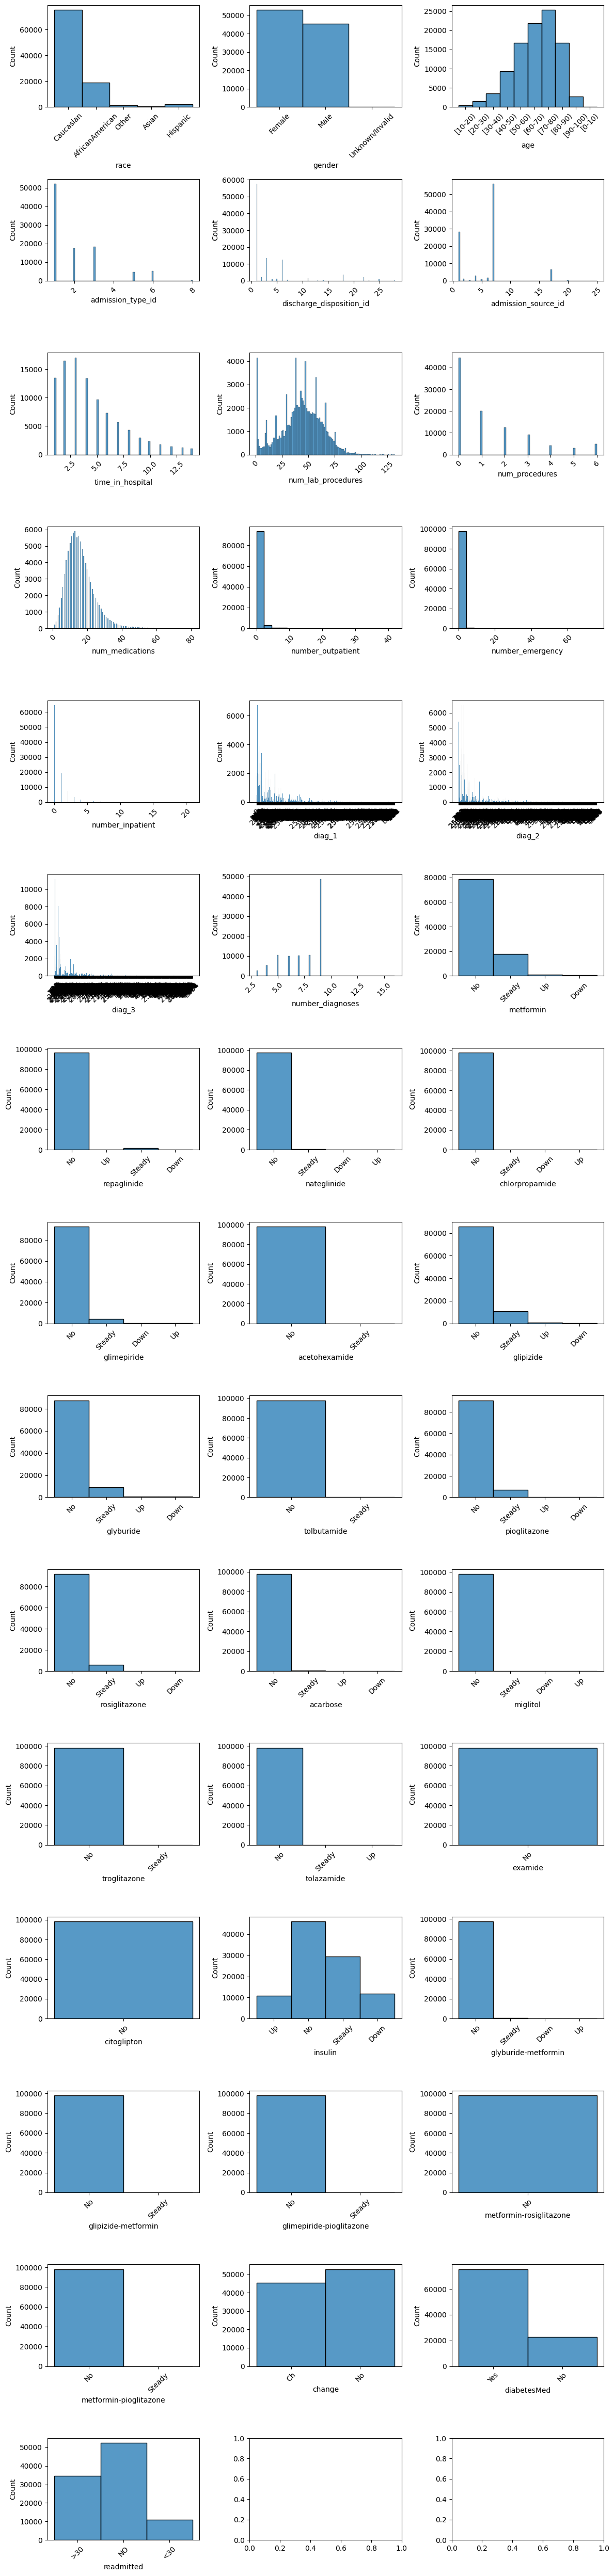

In [9]:
var = df.columns.tolist()

fig, axes = plt.subplots(15, 3, figsize=(12, 50))

axes = axes.flatten()

b = 0
for i in range(len(var)):
    sns.histplot(x=df[var[i]], ax=axes[b])
    axes[b].tick_params(axis="x", rotation=45)
    b += 1

plt.tight_layout()
plt.show()

## 1.1) Regroupement des classes rares :

#### Regroupement des catégories afin de réduire le nombre de variables générées par l’encodage one-hot (OHE) et de limiter le surapprentissage lié aux classes rares.

In [10]:
# Nombre de modalités des variables diag_1, diag_2 et diag_3 (coded as first three digits of ICD-9)

print('nombre de modalités de diag_1 :', df['diag_1'].nunique())
print('nombre de modalités de diag_2 :', df['diag_2'].nunique())
print('nombre de modalités de diag_3 :', df['diag_3'].nunique())

nombre de modalités de diag_1 : 713
nombre de modalités de diag_2 : 740
nombre de modalités de diag_3 : 786


## Regroupement des codes ICD-9 (variables diag_1, diag_2, diag_3)

Lien vers la nomenclature officielle ICD-9 :  
https://www.icd9data.com/2008/Volume1/default.htm

### Modalités originales
Les diagnostics sont fournis sous forme de codes ICD-9 :
- Codes numériques (ex. 250, 401.9, etc.)
- Codes commençant par :
  - V : facteurs influençant l’état de santé
  - E : causes externes
- Valeurs manquantes ou non reconnues

### Nouvelles catégories après regroupement
- 001–139 : Maladies infectieuses  
- 140–239 : Tumeurs  
- 240–279 : Endocriniennes / Métaboliques  
- 280–289 : Maladies du sang  
- 290–319 : Troubles mentaux  
- 320–389 : Système nerveux  
- 390–459 : Circulatoire  
- 460–519 : Respiratoire  
- 520–579 : Digestif  
- 580–629 : Génito-urinaire  
- 630–677 : Grossesse  
- 680–709 : Peau  
- 710–739 : Musculo-squelettique  
- 740–759 : Anomalies congénitales  
- 760–779 : Période périnatale  
- 780–799 : Symptômes  
- 800–999 : Blessures / Empoisonnement  
- V01–V86 : Facteurs influençant la santé  
- E800–E999 : Causes externes  
- Autre / Inconnu : codes non reconnus ou erronés


In [11]:
def ICD9_category(code):
    if pd.isna(code):
        return np.nan

    code = str(code)

    
    if code.startswith('V'):
        return 'V01–V86 : Facteurs influençant la santé'
    if code.startswith('E'):
        return 'E800–E999 : Causes externes'

   
    try:
        code_num = float(code)
    except:
        return 'Autre / Inconnu'

    if 1 <= code_num <= 139:
        return '001–139 : Infectieuses'
    elif 140 <= code_num <= 239:
        return '140–239 : Tumeurs'
    elif 240 <= code_num <= 279:
        return '240–279 : Endocriniennes / Métaboliques'
    elif 280 <= code_num <= 289:
        return '280–289 : Maladies du sang'
    elif 290 <= code_num <= 319:
        return '290–319 : Troubles mentaux'
    elif 320 <= code_num <= 389:
        return '320–389 : Système nerveux'
    elif 390 <= code_num <= 459:
        return '390–459 : Circulatoire'
    elif 460 <= code_num <= 519:
        return '460–519 : Respiratoire'
    elif 520 <= code_num <= 579:
        return '520–579 : Digestif'
    elif 580 <= code_num <= 629:
        return '580–629 : Génito-urinaire'
    elif 630 <= code_num <= 677:
        return '630–677 : Grossesse'
    elif 680 <= code_num <= 709:
        return '680–709 : Peau'
    elif 710 <= code_num <= 739:
        return '710–739 : Musculo-squelettique'
    elif 740 <= code_num <= 759:
        return '740–759 : Anomalies congénitales'
    elif 760 <= code_num <= 779:
        return '760–779 : Période périnatale'
    elif 780 <= code_num <= 799:
        return '780–799 : Symptômes'
    elif 800 <= code_num <= 999:
        return '800–999 : Blessures / Empoisonnement'
    else:
        return 'Autre / Inconnu'


In [12]:
df['diag_1'] = df['diag_1'].apply(ICD9_category)
df['diag_2'] = df['diag_2'].apply(ICD9_category)
df['diag_3'] = df['diag_3'].apply(ICD9_category)

## Regroupement des catégories de la variable admission_type_id

La variable *admission_type_id* décrit le type d’admission à l’hôpital :

### Modalités originales
- 1 : Emergency  
- 2 : Urgent  
- 3 : Elective  
- 4 : Newborn  
- 5 : Not Available  
- 6 : NULL  
- 7 : Trauma Center  
- 8 : Not Mapped  

### Nouvelles catégories après regroupement
- **Urgent** : Emergency (1), Urgent (2), Trauma Center (7)  
- **Autre** : toutes les autres modalités (3, 4, 5, 6, 8)


In [13]:
df['admission_type_id'].value_counts()

admission_type_id
1    52178
3    18194
2    17543
6     5135
5     4661
8      312
7       20
4       10
Name: count, dtype: int64

In [14]:
# Regroupement des catégories pour discharge_disposition_id

def regrouper_type_admission(x):
    if x in [1, 2, 7]:
        return 'Urgent'
    else:
        return 'Autre'

df['admission_type_id'] = df['admission_type_id'].apply(regrouper_type_admission)


## Regroupement des catégories de la variable discharge_disposition_id

La variable *discharge_disposition_id* décrit la situation du patient à la sortie de l’hôpital (retour à domicile, transfert, décès, etc.).  

### Modalités originales

Beacoup de modalités environ 30, voir doc pour plus de précision (annexe doc)

### Nouvelles catégories après regroupement

- **Domicile** :  
  Discharged to home (1),  
  Discharged to home with home health service (6),  
  Discharged to home under care of Home IV provider (8),  
  Hospice / home (13)

- **Établissement de soins** :  
  Transfert vers un autre hôpital ou établissement de soins (2, 3, 4, 5),  
  Rééducation, soins de longue durée ou nursing facility (22, 23, 24),  
  Établissements spécialisés ou fédéraux (27, 28, 29)

- **Décès** :  
  Expired (11),  
  Expired at home / medical facility / place unknown (19, 20, 21)

- **Autre / Suivi** :  
  Autres modalités (retour prévu, suivi ambulatoire, valeurs manquantes ou non mappées)



In [15]:
df['discharge_disposition_id'].value_counts()

discharge_disposition_id
1     57610
3     13564
6     12626
18     3624
2      2049
22     1970
11     1606
5      1127
25      941
4       756
7       592
23      400
13      396
14      368
28      137
8       106
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64

In [16]:
# Regroupement des catégories pour admission_source_id

def regrouper_discharge(x):
    if x in [1, 6, 8, 13]:
        return 'Domicile'

    elif x in [2, 3, 4, 5, 22, 23, 24, 27, 28, 29]:
        return 'Établissement de soins'

    elif x in [11, 19, 20, 21]:
        return 'Décès'
    
    else:
        return 'Autre / Suivi'

df['discharge_disposition_id'] = df['discharge_disposition_id'].apply(regrouper_discharge)

## Regroupement des catégories de la variable admission_source_id

La variable *admission_source_id* indique l’origine de l’admission du patient à l’hôpital (référence médicale, urgence, transfert, naissance, etc.).  

### Modalités originales

Beacoup de modalités environ 30, voir doc pour plus de précision (annexe doc)

### Nouvelles catégories après regroupement

- **Référence médicale** :  
  Physician Referral (1),  
  Clinic Referral (2),  
  HMO Referral (3)

- **Urgence** :  
  Emergency Room (7)

- **Transfert établissement** :  
  Transfer from a hospital (4),  
  Transfer from a Skilled Nursing Facility (5),  
  Transfer from another health care facility (6),  
  Transfer from critical access hospital (10),  
  Transfer From Another Home Health Agency (18),  
  Readmission to Same Home Health Agency (19),  
  Transfer from hospital inpatient / same facility (22),  
  Transfer from Ambulatory Surgery Center (25),  
  Transfer from Hospice (26)

- **Naissance** :  
  Normal Delivery (11),  
  Premature Delivery (12),  
  Sick Baby (13),  
  Extramural Birth (14),  
  Born inside this hospital (23),  
  Born outside this hospital (24)

- **Autre** :  
  Autres modalités (justice, non disponible, non mappé, inconnu ou valeurs manquantes)



In [17]:
df['admission_source_id'].value_counts()

admission_source_id
7     55951
1     28356
17     6602
4      2945
6      1893
2      1031
5       846
3       179
20      160
9        49
8        15
22       12
10        7
14        2
11        2
25        2
13        1
Name: count, dtype: int64

In [18]:
# Regroupement des catégories pour admission_source_id

def regrouper_admission_source(x):
    if x in [1, 2, 3]:
        return 'Référence médicale'

    elif x == 7:
        return 'Urgence'

    elif x in [4, 5, 6, 10, 18, 19, 22, 25, 26]:
        return 'Transfert établissement'

    elif x in [11, 12, 13, 14, 23, 24]:
        return 'Naissance'

    else:
        return 'Autre'

df['admission_source_id'] = df['admission_source_id'].apply(regrouper_admission_source)

## Regroupement des catégories de la variable race

### Modalités originales
- Caucasian  
- AfricanAmerican  
- Hispanic  
- Asian  
- Other  


### Nouvelles catégories après regroupement

- **Caucasian**
- **AfricanAmerican**
- **Other** : Asian, Hispanic, Other



In [19]:
df['race'].value_counts()

race
Caucasian          75079
AfricanAmerican    18881
Hispanic            1984
Other               1484
Asian                625
Name: count, dtype: int64

In [20]:
df = df.replace({'race': {'Asian': 'Other',
                   'Hispanic': 'Other'}})

## Regroupement des modalités des variables de médication

### Modalités originales

- **No** : médicament non prescrit  
- **Steady** : dosage inchangé  
- **Up** : augmentation du dosage  
- **Down** : diminution du dosage  

### Nouvelles modalités après regroupement

- **0** : médicament non prescrit (*No*)
- **1** : médicament prescrit ou modifié (*Steady*, *Up*, *Down*)


In [21]:
# binarisation des médicaments

def regrouper_medictation(var):
    df[var] = df[var].apply(
    lambda x: 0 if x == 'No' else 1
)
    

regrouper_medictation('metformin')
regrouper_medictation('repaglinide')
regrouper_medictation('glimepiride')
regrouper_medictation('glipizide')
regrouper_medictation('glyburide')
regrouper_medictation('pioglitazone')
regrouper_medictation('rosiglitazone')
regrouper_medictation('acarbose')
regrouper_medictation('miglitol')
regrouper_medictation('troglitazone')
regrouper_medictation('tolazamide')
regrouper_medictation('glyburide-metformin')
regrouper_medictation('glipizide-metformin')
regrouper_medictation('nateglinide')
regrouper_medictation('chlorpropamide')
regrouper_medictation('acetohexamide')
regrouper_medictation('tolbutamide')
regrouper_medictation('examide')
regrouper_medictation('citoglipton')
regrouper_medictation('glimepiride-pioglitazone')
regrouper_medictation('metformin-rosiglitazone')
regrouper_medictation('metformin-pioglitazone')


# 1.2) Encodage des variables catégorielles

In [22]:
df['gender'].value_counts()

gender
Female             52833
Male               45219
Unknown/Invalid        1
Name: count, dtype: int64

In [23]:
# on supprime la valeur anormale 
df = df[df['gender'] != 'Unknown/Invalid']

In [24]:
# Encodage de la variable

df['gender'] = np.where(
    (df['gender'] == 'Female'),
    1,
    0
)

In [25]:
# Encodage de la variable

df['change'] = np.where(
    (df['change'] == 'Ch'),
    1,
    0
)

In [26]:
# Encodage de la variable

df['diabetesMed'] = np.where(
    (df['diabetesMed'] == 'Yes'),
    1,
    0
)

In [27]:
df['admission_source_id'].value_counts() 

admission_source_id
Urgence                    55951
Référence médicale         29565
Autre                       6826
Transfert établissement     5705
Naissance                      5
Name: count, dtype: int64

In [28]:
# supp calsse trop rare 
df = df[df['admission_source_id'] != 'Naissance']

In [29]:
# Encodage des variables catégorielles ordinale

age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

age_encoder = OrdinalEncoder(categories=[age_order])

df["age"] = age_encoder.fit_transform(df[["age"]])

insulin_order = [ 'No', 'Steady', 'Up', 'Down'
]

insulin_order_encoder = OrdinalEncoder(categories=[insulin_order])

df["insulin"] = insulin_order_encoder.fit_transform(df[["insulin"]])


On remarque que parmis nos variables catégorielles, un certain nombre n'apportent que très peu d'informations. Par exemple examide et citoglipton n'ont qu'une seule modalité. 

D'autres varaibles comme troglitiazone, tolazamide ont plus de modalités mais une seule modalité domine largement les autres.

Nous allons donc supprimer ces variables catégorielles peu informatives.

In [30]:
# On supprime les colonnes catégorielles où une seule modalité représente plus de 99% des valeurs
cols_to_drop = []

for i in var:
    freq_max = df[i].value_counts(normalize=True).max()
    if freq_max >= 0.99:
        cols_to_drop.append(i)

df = df.drop(columns=cols_to_drop)

print("Colonnes supprimées :", cols_to_drop)


Colonnes supprimées : ['nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


In [31]:
# on fait ça juste pour avoir des plus beau graph

var = df.columns.tolist()
var.remove('diag_1')
var.remove('diag_2')
var.remove('diag_3')

# 1.3) Visualisations après prétraitement des varaibles

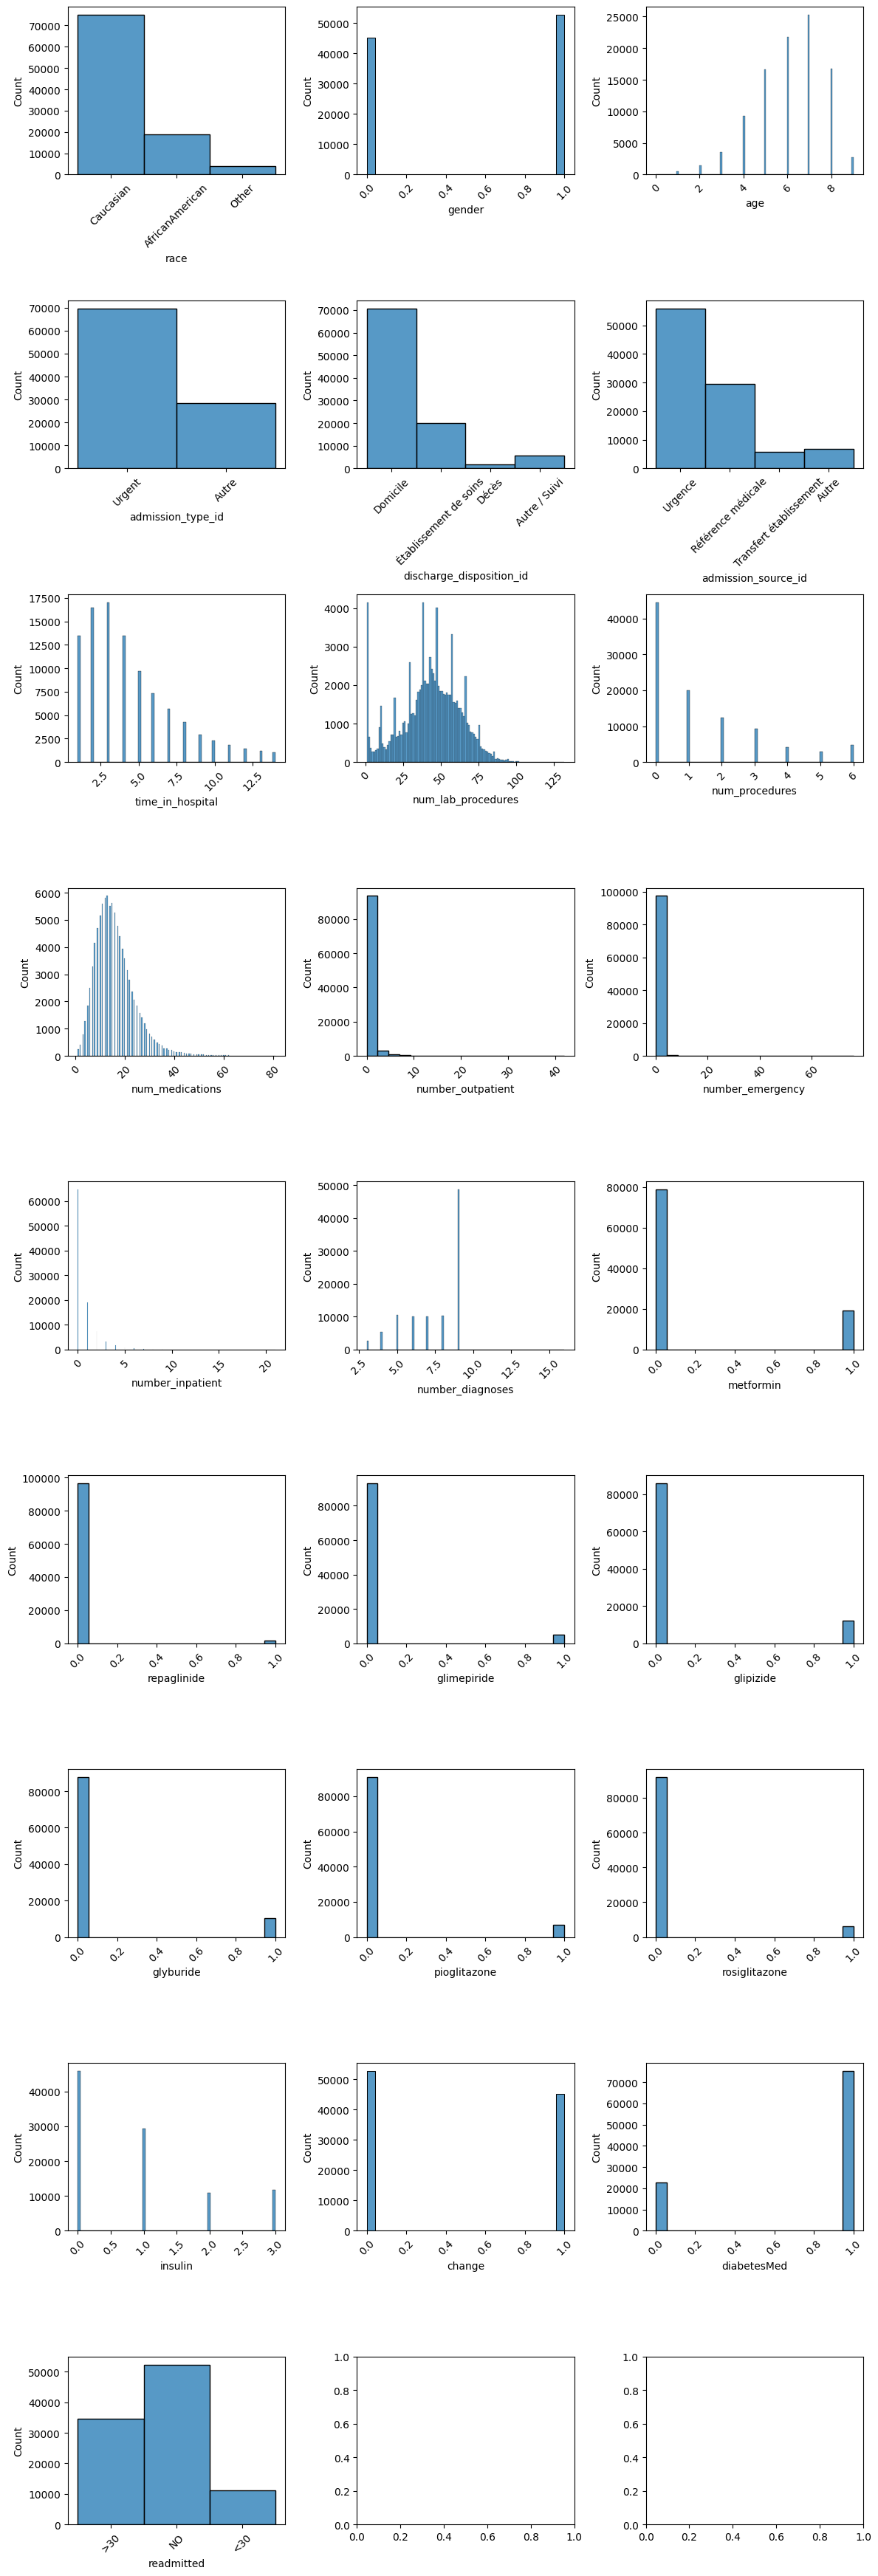

In [32]:
fig, axes = plt.subplots(9, 3, figsize=(12, 35))

axes = axes.flatten()

b = 0
for i in range(len(var)):
    sns.histplot(x=df[var[i]], ax=axes[b])
    axes[b].tick_params(axis="x", rotation=45)
    b += 1

plt.tight_layout()
plt.show()

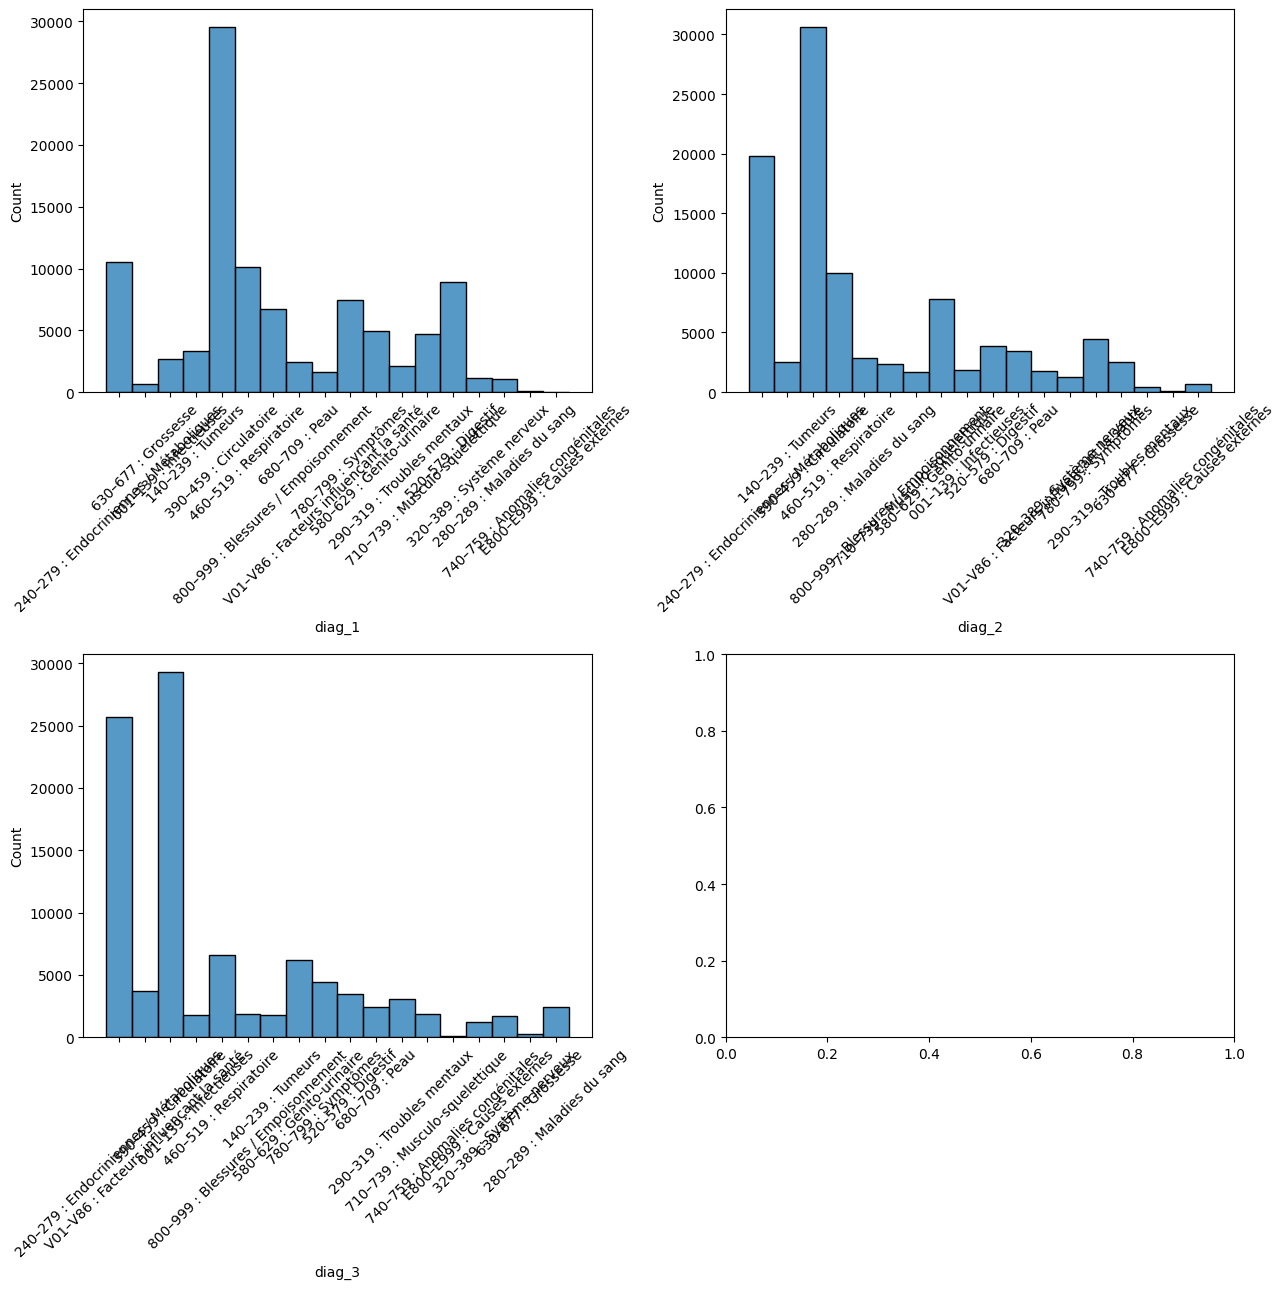

In [33]:
diag = ['diag_1', 'diag_2', 'diag_3']

fig, axes = plt.subplots(2, 2, figsize=(13, 13))

axes = axes.flatten()

b = 0
for i in range(len(diag)):
    sns.histplot(x=df[diag[i]], ax=axes[b])
    axes[b].tick_params(axis="x", rotation=45)
    b += 1

plt.tight_layout()
plt.show()

# 1.3) création de la variables admis 

## Choix de la variable cible

Nous avons choisi de ne conserver que deux classes pour la variable cible :  
**réadmis sous 30 jours : oui / non**.

À l’origine, la variable *readmitted* comportait trois modalités (réadmis sous 30 jours, réadmis après plus de 30 jours, non réadmis).  
Nous aurions pu essayer de prédire ces trois classes, mais notre objectif principal était surtout d’identifier les patients qui sont réadmis rapidement après leur hospitalisation.

Les réadmissions au-delà de 30 jours peuvent être liées à des événements indépendants de l’hospitalisation initiale pour le diabète (par exemple un accident ou une autre pathologie). Comme nous n’avons pas d’information précise sur la raison de ces réadmissions tardives, les inclure comme une classe à part aurait ajouté du bruit au modèle.

La binarisation permet donc de se concentrer sur un signal plus pertinent, de simplifier le problème et de mieux répondre à l’objectif du projet.


In [34]:
# Création de la variable cible 'admis' à partir de 'readmitted'
df['admis'] = np.where(
    (df['readmitted'] == 'NO') | (df['readmitted'] == '>30'),
    0,
    1
)


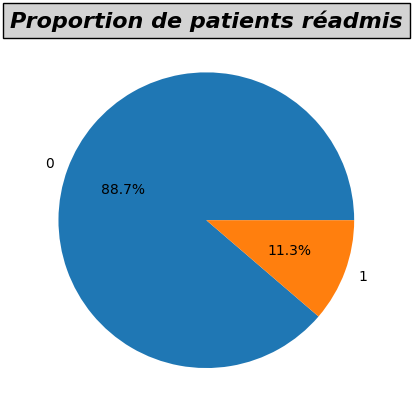

In [35]:
fig, ax = plt.subplots()

counts = df['admis'].value_counts()

ax.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%'
)

ax.set_title('Proportion de patients réadmis', fontsize=16, weight='bold', loc='center', fontstyle='italic',  bbox={'facecolor':'lightgrey', 'pad':5})

plt.show()



# 2) Modélisation : 

In [36]:
# Separation train / test

X = df.drop(columns=["readmitted", "admis"])  
Y =  df["admis"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

In [37]:
X_train.to_csv("données/X_train.csv", index=False, encoding="utf-8")
Y_train.to_csv("données/Y_train.csv", index=False, encoding="utf-8")



X_test.to_csv("données/X_test.csv", index=False, encoding="utf-8")
Y_test.to_csv("données/Y_est.csv", index=False, encoding="utf-8")

# 2.1) Hot One Encoding des variables catégorielles.

### Les variables diag_1, diag_2 et diag_3 pouvant contenir jusqu’à trois diagnostics par patient, nous avons créé des variables indicatrices correspondant aux grandes catégories ICD-9.  
### Chaque variable indique la présence ou l’absence d’au moins un diagnostic appartenant à la catégorie considérée.  
### Cette approche permet de conserver l’information clinique tout en évitant une explosion du nombre de variables après encodage.


In [38]:
diag_cols = ["diag_1", "diag_2", "diag_3"]

In [39]:
icd_categories = [
    '001–139 : Infectieuses',
    '140–239 : Tumeurs',
    '240–279 : Endocriniennes / Métaboliques',
    '280–289 : Maladies du sang',
    '290–319 : Troubles mentaux',
    '320–389 : Système nerveux',
    '390–459 : Circulatoire',
    '460–519 : Respiratoire',
    '520–579 : Digestif',
    '580–629 : Génito-urinaire',
    '630–677 : Grossesse',
    '680–709 : Peau',
    '710–739 : Musculo-squelettique',
    '740–759 : Anomalies congénitales',
    '760–779 : Période périnatale',
    '780–799 : Symptômes',
    '800–999 : Blessures / Empoisonnement',
    'V01–V86 : Facteurs influençant la santé',
    'E800–E999 : Causes externes'
]

In [40]:
def add_icd_columns(df, a, b):
    df = df.copy()

    for cat in b:
        col_name = "icd_" + cat.split(" : ")[0].replace("–", "_")

        df[col_name] = (
            df[a]
            .eq(cat)
            .any(axis=1)
            .astype(int)
        )

    return df.drop(columns=a)


In [41]:
X_train = add_icd_columns(X_train, a=diag_cols, b=icd_categories)
X_test  = add_icd_columns(X_test,  a=diag_cols, b=icd_categories)

In [42]:
# Colonnes catégorielles à encoder et normalisation

categorical_cols = ["race", "discharge_disposition_id", "admission_source_id", "admission_type_id"]

numeric_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications","number_diagnoses", "number_outpatient", "number_emergency", "number_inpatient"]

encoder = ColumnTransformer(
    [   ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)


X_train_encoded = encoder.fit_transform(X_train)

X_test_encoded = encoder.transform(X_test)



In [43]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)


(78437, 48)
(19610, 48)


In [44]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(),
    index=X_train.index
)

X_train_encoded.columns = X_train_encoded.columns.str.replace("remainder__", "", regex=False)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(),
    index=X_test.index
)

X_test_encoded_df.columns = X_test_encoded_df.columns.str.replace("remainder__", "", regex=False)

In [45]:
X_train_encoded.head()

,num__time_in_hospital,num__num_lab_procedures,num__num_procedures,num__num_medications,num__number_diagnoses,num__number_outpatient,num__number_emergency,num__number_inpatient,cat__race_Caucasian,cat__race_Other,...,icd_580_629,icd_630_677,icd_680_709,icd_710_739,icd_740_759,icd_760_779,icd_780_799,icd_800_999,icd_V01_V86,icd_E800_E999
30006,-1.145057,-0.615780,0.965354,0.230631,-1.921710,1.288949,-0.214732,-0.510517,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
46759,-0.810942,-2.137410,-0.789212,-0.508643,0.811003,0.496215,-0.214732,-0.510517,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
85363,-0.810942,-2.137410,-0.204357,-0.139006,-0.282082,-0.296518,-0.214732,0.275187,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33902,-0.142712,0.297199,1.550209,0.600269,-1.375167,-0.296518,-0.214732,0.275187,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88854,1.861980,0.094315,1.550209,0.600269,0.811003,-0.296518,-0.214732,-0.510517,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 2.2) Baseline models avec Dummy Classifier
### Benchmark le plus simple possible avec Dummy Classifier

In [46]:
dummy = DummyClassifier(strategy="stratified", random_state=42) # Modèle

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Cross validation stratifiée

# Métriques d’évaluation utilisées lors de la validation croisée
scoring = {
        "pr_auc": "average_precision",
        "recall": "recall",
        "roc_auc": "roc_auc",
        "f1": "f1",
        "precision": "precision"
    }



In [47]:
cv_results = cross_validate(
    dummy,
    X_train_encoded,
    Y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)


print("===== DummyClassifier — Cross-Validation (TRAIN) =====")
for metric in cv_results:
    if metric.startswith("test_"):
        scores = cv_results[metric]
        print(f"{metric.replace('test_', '').upper():<15}: "
              f"{scores.mean():.4f} ± {scores.std():.4f}")

===== DummyClassifier — Cross-Validation (TRAIN) =====
PR_AUC         : 0.1130 ± 0.0008
RECALL         : 0.1123 ± 0.0069
ROC_AUC        : 0.5006 ± 0.0039
F1             : 0.1131 ± 0.0069
PRECISION      : 0.1139 ± 0.0070



===== DummyClassifier — TEST =====
ROC_AUC             : 0.5009
PR_AUC              : 0.1130
Recall_1            : 0.1148
Precision_1         : 0.1144
F1_1                : 0.1146

Prévalence classe positive (TEST): 0.1129

===== Matrice de confusion — TEST =====
          Pred_0  Pred_1
Actual_0   15430    1967
Actual_1    1959     254


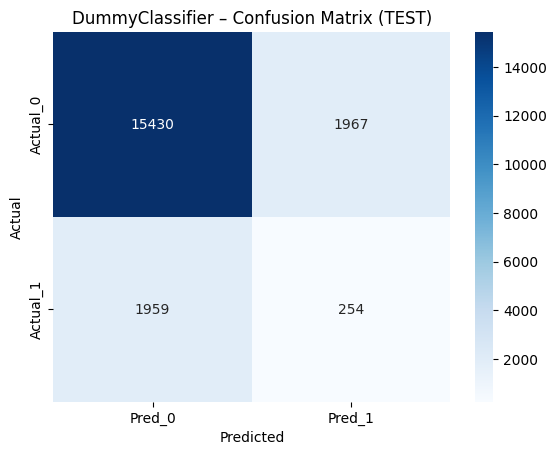

In [65]:
# Entrainemneyt + pred

dummy.fit(X_train_encoded, Y_train)

y_proba_test_dummy = dummy.predict_proba(X_test_encoded)[:, 1]
y_pred_test_dummy = (y_proba_test_dummy >= 0.5).astype(int)

# metrics

test_metrics = {
    "ROC_AUC": roc_auc_score(Y_test, y_proba_test_dummy),
    "PR_AUC": average_precision_score(Y_test, y_proba_test_dummy),
    "Recall_1": recall_score(Y_test, y_pred_test_dummy),
    "Precision_1": precision_score(Y_test, y_pred_test_dummy),
    "F1_1": f1_score(Y_test, y_pred_test_dummy),
}

print("\n===== DummyClassifier — TEST =====")
for k, v in test_metrics.items():
    print(f"{k:<20}: {v:.4f}")

print("\nPrévalence classe positive (TEST): "
      f"{Y_test.mean():.4f}")


# Matrice de confusion

cm = confusion_matrix(Y_test, y_pred_test_dummy)

cm_df = pd.DataFrame(
    cm,
    index=["Actual_0", "Actual_1"],
    columns=["Pred_0", "Pred_1"]
)

print("\n===== Matrice de confusion — TEST =====")
print(cm_df)

sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("DummyClassifier – Confusion Matrix (TEST)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 2.3) Regression logistique

In [49]:
# Selection des hyperparamètre par cross-validation

# logit elastic net
logit_enet_cv = LogisticRegressionCV(
    Cs=[0.01, 0.1, 1],
    l1_ratios=[0.3, 0.5, 0.7],
    cv=5,
    penalty="elasticnet",
    solver="saga",
    scoring="f1",
    class_weight="balanced",
    max_iter=3000,
    n_jobs=-1
)

logit_enet_cv.fit(X_train_encoded, Y_train)

best_C_enet = logit_enet_cv.C_[0]
best_l1_ratio = logit_enet_cv.l1_ratio_[0]

# logit + lasso
logit_l1_cv = LogisticRegressionCV(
    Cs=[0.01, 0.1, 1, 10],
    cv=5,
    penalty="l1",
    solver="saga",
    scoring="f1",
    class_weight="balanced",
    max_iter=3000,
    n_jobs=-1
)

logit_l1_cv.fit(X_train_encoded, Y_train)

best_C_l1 = logit_l1_cv.C_[0]



In [50]:
models = {

   
    # 1️) LOGIT "PUR" 
    "Logit": LogisticRegression(
        penalty=None,           
        solver="lbfgs",         
        class_weight="balanced",
        max_iter=2000           
    ),

    # - baseline
    # - Très sensible au sur-apprentissage

    # 2️) LOGIT + L2 (Ridge)
    "Logit_L2": LogisticRegression(
        penalty="l2",           #  Régularisation Ridge
        solver="lbfgs",
        class_weight="balanced",
        max_iter=2000
    ),
 
    # - Réduit le sur-apprentissage
    # - Stabilise les coefficients
    # - Gère bien la multicolinéarité

    # - Ne fait PAS de sélection de variables
    # - Toutes les variables restent dans le modèle


    # 3️) LOGIT + L2 avec régularisation FORTE
    "Logit_L2_C01": LogisticRegression(
        penalty="l2",
        C=0.1,                  # Régularisation plus forte (C ↓ ⇒ pénalité ↑)
        solver="lbfgs",
        class_weight="balanced",
        max_iter=2000
    ),

    # - Très bonne généralisation
    # - Moins sensible au bruit
    # - Peut sous-ajuster si C trop petit

    # 4️) LOGIT + L1 (Lasso)
    "Logit_L1": LogisticRegression(
        penalty="l1",            # Régularisation Lasso
        C=best_C_l1,             # Hyperparamètre optimisé
        solver="saga",           
        class_weight="balanced",
        max_iter=3000
    ),
   
    # - Sélection automatique de variables
    # - Coefficients inutiles = 0


    # 5️) LOGIT + ELASTIC NET (L1 + L2)

    "ElasticNet": LogisticRegression(
        penalty="elasticnet",    
        C=best_C_enet,           
        l1_ratio=best_l1_ratio,  
        solver="saga",
        class_weight="balanced",
        max_iter=3000
    )
 
    # - Sélection de variables + stabilité
    # - Gère très bien les variables corrélées
}


In [51]:
print("===== Logistic Regression — Cross-Validation (TRAIN) =====")

cv_results_summary = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train_encoded,
        Y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    print(f"\n{name}")
    print(f"ROC_AUC   : {scores['test_roc_auc'].mean():.4f}")
    print(f"PR_AUC    : {scores['test_pr_auc'].mean():.4f}")
    print(f"Recall_1  : {scores['test_recall'].mean():.4f}")
    print(f"Precision : {scores['test_precision'].mean():.4f}")
    print(f"F1_1      : {scores['test_f1'].mean():.4f}")

    cv_results_summary.append({
        "Model": name,
        "ROC_AUC": scores["test_roc_auc"].mean(),
        "PR_AUC": scores["test_pr_auc"].mean(),
        "Recall": scores["test_recall"].mean(),
        "Precision": scores["test_precision"].mean(),
        "F1": scores["test_f1"].mean()
    })

cv_results_df = pd.DataFrame(cv_results_summary)
cv_results_df.sort_values("PR_AUC", ascending=False)


===== Logistic Regression — Cross-Validation (TRAIN) =====

Logit
ROC_AUC   : 0.6585
PR_AUC    : 0.2020
Recall_1  : 0.5556
Precision : 0.1774
F1_1      : 0.2689

Logit_L2
ROC_AUC   : 0.6585
PR_AUC    : 0.2021
Recall_1  : 0.5553
Precision : 0.1775
F1_1      : 0.2689

Logit_L2_C01
ROC_AUC   : 0.6587
PR_AUC    : 0.2020
Recall_1  : 0.5528
Precision : 0.1776
F1_1      : 0.2689

Logit_L1
ROC_AUC   : 0.6591
PR_AUC    : 0.2023
Recall_1  : 0.5546
Precision : 0.1777
F1_1      : 0.2691

ElasticNet
ROC_AUC   : 0.6595
PR_AUC    : 0.2024
Recall_1  : 0.5452
Precision : 0.1788
F1_1      : 0.2692


,Model,ROC_AUC,PR_AUC,Recall,Precision,F1
4,ElasticNet,0.659471,0.202448,0.545238,0.178785,0.269249
3,Logit_L1,0.659062,0.202294,0.554613,0.177687,0.269122
1,Logit_L2,0.658529,0.202074,0.555291,0.177466,0.268947
2,Logit_L2_C01,0.658688,0.202046,0.552806,0.177648,0.268861
0,Logit,0.658530,0.202044,0.555629,0.177416,0.268930


## Choix des métriques d’évaluation

**Dans un contexte de déséquilibre des classes**, les métriques basées sur la simple **exactitude** sont écartées au profit d’**indicateurs plus informatifs**.

**Le ROC-AUC** mesure la capacité globale du modèle à discriminer les classes **indépendamment du seuil**, ce qui en fait une métrique utile pour **comparer des modèles**, mais elle peut rester **optimiste** lorsque la classe positive est rare.

**Le PR-AUC**, plus exigeant, se concentre sur le **compromis precision–recall** de la classe positive et constitue donc une **métrique clé** lorsque l’objectif est de détecter efficacement la **classe minoritaire**.

**Le recall de la classe 1** évalue la capacité du modèle à identifier les **observations positives**, ce qui est essentiel lorsque le **coût des faux négatifs est élevé**, au prix potentiel d’une augmentation des **faux positifs**.

**La precision** complète cette analyse en mesurant la **fiabilité des prédictions positives**, mais peut être élevée même si **peu d’observations positives** sont détectées.

**Enfin, le F1-score**, e  
n combinant **precision** et **recall**, offre un **compromis équilibré** et sert souvent de **métrique synthétique de référence** lorsque les coûts d’erreurs ne sont pas clairement définis.

**Dans ce cadre**, le **PR-AUC** et le **F1-score** sont généralement les **indicateurs les plus pertinents** pour évaluer la performance réelle du modèle sur la **classe minoritaire**.


In [52]:
# les modèles deonne des résultast très similaire on va garder le Logit L2 car il snt très proche en PR_AUC dif de 0.0001 mais est meiux en recall 
# ElasticNet 

In [53]:
# Fonction métriques de performance

def metrics_comparison(
    y_true,
    y_pred,
    y_proba,
    y_pred_bench,
    y_proba_bench,
    model_name="Model",
    benchmark_name="Benchmark"
):
    

    metrics_model = {
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
        "Recall_1": recall_score(y_true, y_pred),
        "Precision_1": precision_score(y_true, y_pred),
        "F1_1": f1_score(y_true, y_pred),
    }

   
    metrics_bench = {
        "ROC_AUC": roc_auc_score(y_true, y_proba_bench),
        "PR_AUC": average_precision_score(y_true, y_proba_bench),
        "Recall_1": recall_score(y_true, y_pred_bench),
        "Precision_1": precision_score(y_true, y_pred_bench),
        "F1_1": f1_score(y_true, y_pred_bench),
    }

   
    df = pd.DataFrame({
        model_name: metrics_model,
        benchmark_name: metrics_bench
    })

    df["Δ"] = df[model_name] - df[benchmark_name]

    print(f"\n===== {model_name} vs {benchmark_name} — TEST =====\n")
    print(df.round(4).to_string())

    return df





def plot_roc_comparison(
    y_true,
    y_proba_dict,
    title="ROC Curve Comparison"
):
    
    plt.figure(figsize=(7, 6))

    for model_name, y_proba in y_proba_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc = roc_auc_score(y_true, y_proba)
        plt.plot(
            fpr,
            tpr,
            label=f"{model_name} (AUC = {roc_auc:.3f})"
        )


    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_pr_comparison(
    y_true,
    y_proba_dict,
    title="Precision–Recall Curve Comparison",
    show_baseline=True
):
    plt.figure(figsize=(7, 6))

    for model_name, y_proba in y_proba_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        pr_auc = average_precision_score(y_true, y_proba)

        plt.plot(
            recall,
            precision,
            label=f"{model_name} (PR-AUC = {pr_auc:.3f})"
        )

    if show_baseline:
        baseline = y_true.mean()
        plt.hlines(
            baseline,
            xmin=0,
            xmax=1,
            linestyles="dashed",
            colors="gray",
            label="Baseline (prevalence)"
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()







def plot_confusion_matrices(
    y_true,
    y_pred_1,
    y_pred_2,
    model_names=("Model 1", "Model 2"),
    normalize=False,
    cmap="Blues"
):
   

    if normalize:
        cm1 = confusion_matrix(y_true, y_pred_1, normalize="true")
        cm2 = confusion_matrix(y_true, y_pred_2, normalize="true")
        fmt = ".2f"
    else:
        cm1 = confusion_matrix(y_true, y_pred_1)
        cm2 = confusion_matrix(y_true, y_pred_2)
        fmt = "d"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ax, cm, name in zip(axes, [cm1, cm2], model_names):
        cm_df = pd.DataFrame(
            cm,
            index=["Actual_0", "Actual_1"],
            columns=["Pred_0", "Pred_1"]
        )

        sns.heatmap(
            cm_df,
            annot=True,
            fmt=fmt,
            cmap=cmap,
            ax=ax
        )
        ax.set_title(f"{name}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.show()



In [54]:
# Recréation explicite du meilleur modèle
best_model = LogisticRegression(
     penalty="elasticnet",
        C=best_C_enet,
        l1_ratio=best_l1_ratio,
        solver="saga",
        class_weight="balanced",
        max_iter=3000
)


best_model.fit(X_train_encoded, Y_train)

y_proba_test_logit = best_model.predict_proba(X_test_encoded)[:, 1]
y_pred_test_logit = (y_proba_test_logit >= 0.5).astype(int)

/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



===== Logistic Regression (ElasticNet) vs DummyClassifier — TEST =====

             Logistic Regression (ElasticNet)  DummyClassifier       Δ
ROC_AUC                                0.6522           0.5009  0.1513
PR_AUC                                 0.2019           0.1130  0.0888
Recall_1                               0.5364           0.1148  0.4216
Precision_1                            0.1766           0.1144  0.0623
F1_1                                   0.2658           0.1146  0.1512


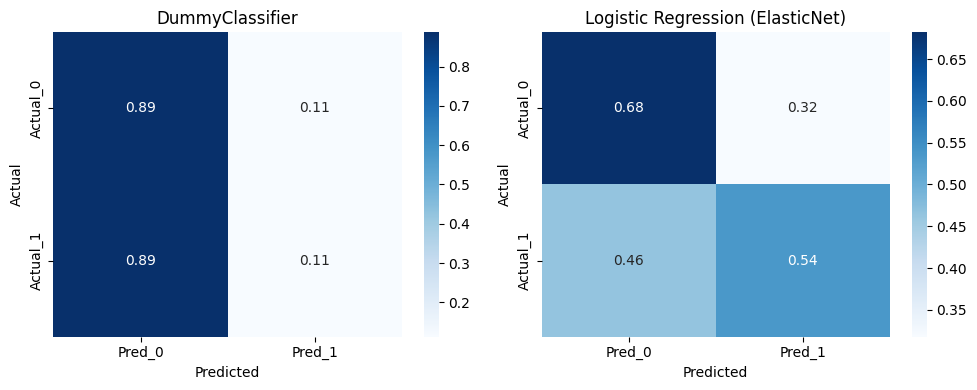

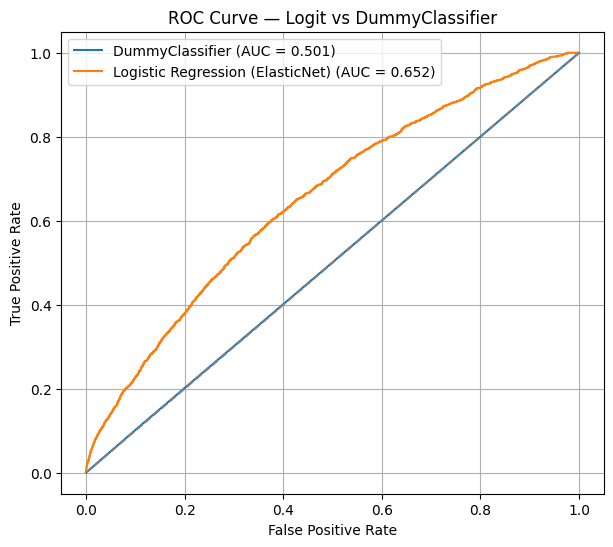

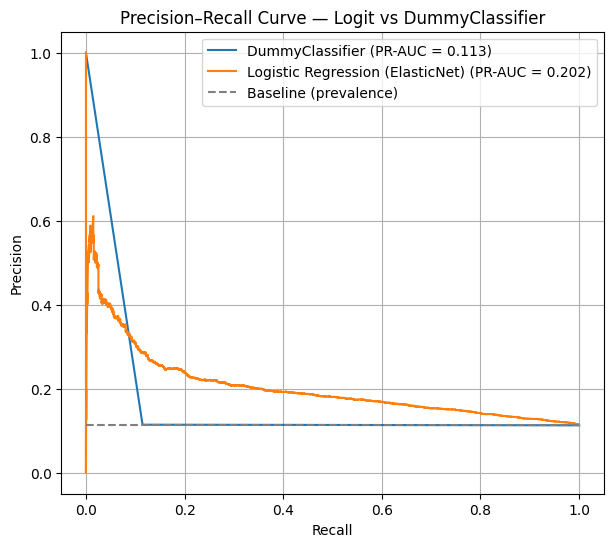

In [63]:
metrics_comparison(
    y_true=Y_test,
    y_pred=y_pred_test_logit,
    y_proba=y_proba_test_logit,
    y_pred_bench=y_pred_test_dummy,
    y_proba_bench=y_proba_test_dummy,
    model_name="Logistic Regression (ElasticNet)",
    benchmark_name="DummyClassifier"
)

plot_confusion_matrices(
    Y_test,
    y_pred_test_dummy,
    y_pred_test_logit,
    model_names=("DummyClassifier", "Logistic Regression (ElasticNet)"
                 ), 
    normalize="true")


plot_roc_comparison(
    Y_test,
    {
        "DummyClassifier": y_proba_test_dummy,
        "Logistic Regression (ElasticNet)": y_proba_test_logit
    },
    title="ROC Curve — Logit vs DummyClassifier"
)

plot_pr_comparison(
    Y_test,
    {
        "DummyClassifier": y_proba_test_dummy,
        "Logistic Regression (ElasticNet)": y_proba_test_logit
    },
    title="Precision–Recall Curve — Logit vs DummyClassifier"
)

## Conclusion

La régression logistique avec régularisation **Elastic Net** constitue un modèle à la fois **simple** et **interprétable**, ce qui en fait un bon point de départ pour l’analyse.

Bien que ses performances restent perfectibles, elle fournit une base solide pour l'analyse

In [56]:
# On peut essayer d'ajuster le seuil de décision pour améliorer les résultats

y_proba_train_logit = best_model.predict_proba(X_train_encoded)[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)

results_thresholds = []


for t in thresholds:
    y_pred_train_logit = (y_proba_train_logit >= t).astype(int)

    results_thresholds.append({
        "threshold": t,
        "recall": recall_score(Y_train, y_pred_train_logit),
        "precision": precision_score(Y_train, y_pred_train_logit),
        "f1": f1_score(Y_train, y_pred_train_logit),
        "pr_auc": average_precision_score(Y_train, y_proba_train_logit)
    })

thresholds_df = pd.DataFrame(results_thresholds)

In [59]:
thresholds_df.sort_values("f1", ascending=False).head(10)


,threshold,recall,precision,f1,pr_auc
41,0.51,0.521857,0.183494,0.271517,0.203196
40,0.50,0.550548,0.179779,0.271049,0.203196
39,0.49,0.576867,0.176627,0.270448,0.203196
38,0.48,0.604428,0.173475,0.269579,0.203196
37,0.47,0.634474,0.170522,0.268801,0.203196
42,0.52,0.488196,0.185311,0.268647,0.203196
43,0.53,0.458263,0.188269,0.266890,0.203196
36,0.46,0.663165,0.166539,0.266222,0.203196
35,0.45,0.692195,0.162108,0.262694,0.203196
44,0.54,0.425167,0.189976,0.262611,0.203196


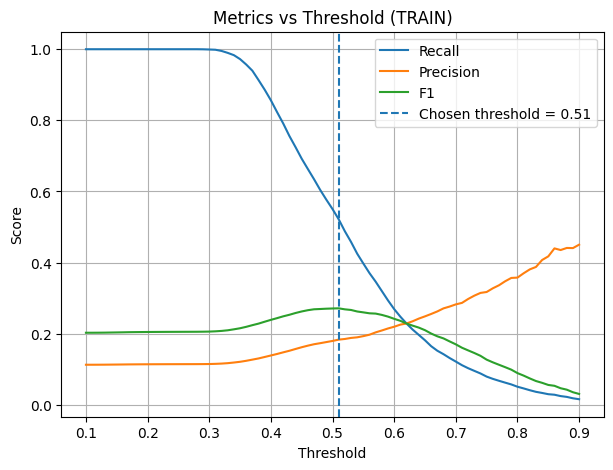

In [60]:
best_threshold = 0.51

plt.figure(figsize=(7, 5))
plt.plot(thresholds_df["threshold"], thresholds_df["recall"], label="Recall")
plt.plot(thresholds_df["threshold"], thresholds_df["precision"], label="Precision")
plt.plot(thresholds_df["threshold"], thresholds_df["f1"], label="F1")
plt.axvline(best_threshold, linestyle="--", label=f"Chosen threshold = {best_threshold}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metrics vs Threshold (TRAIN)")
plt.legend()
plt.grid(True)
plt.show()


/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



===== Logistic Regression (ElasticNet) - Optimized Threshold vs Logistic Regression (ElasticNet) — TEST =====

             Logistic Regression (ElasticNet) - Optimized Threshold  Logistic Regression (ElasticNet)       Δ
ROC_AUC                                                      0.6522                            0.6522  0.0000
PR_AUC                                                       0.2019                            0.2019  0.0000
Recall_1                                                     0.5084                            0.5364 -0.0280
Precision_1                                                  0.1799                            0.1766  0.0032
F1_1                                                         0.2657                            0.2658 -0.0000


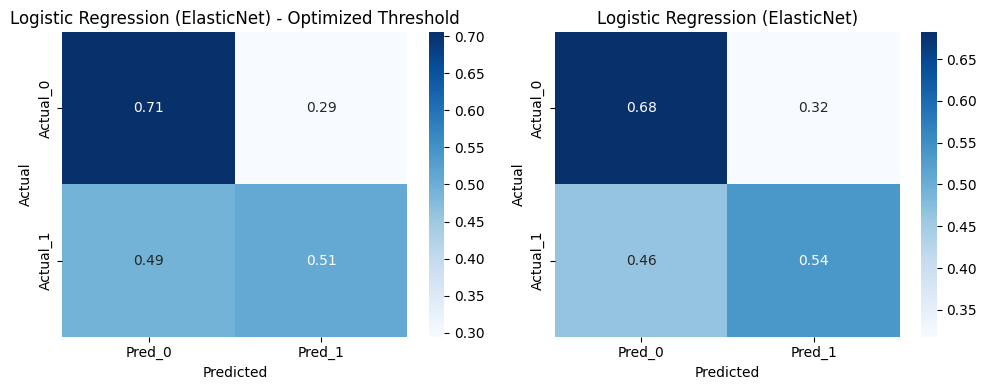

In [66]:


# Probabilités TEST
y_proba_test_opt = best_model.predict_proba(X_test_encoded)[:, 1]

# Prédictions avec seuil optimisé
y_pred_test_opt = (y_proba_test_opt >= best_threshold).astype(int)

metrics_comparison(
    Y_test,
    y_pred_test_opt,
    y_proba_test_opt,
    y_pred_test_logit,
    y_proba_test_logit,
    model_name="Logistic Regression (ElasticNet) - Optimized Threshold",
    benchmark_name="Logistic Regression (ElasticNet)"
)

plot_confusion_matrices(
    Y_test,
    y_pred_test_opt,
    y_pred_test_logit,
    normalize="true",
    model_names=(
        "Logistic Regression (ElasticNet) - Optimized Threshold",
        "Logistic Regression (ElasticNet)"
    )
)


## Impact de l’optimisation du seuil de décision

Le modèle devient légèrement plus conservateur : il détecte un peu moins de réadmissions sous 30 jours (baisse du recall), mais produit marginalement moins de fausses alertes, ce qui se traduit par une légère amélioration de la précision.

Le **F1-score** reste pratiquement inchangé, indiquant que le compromis global entre détection et fiabilité des prédictions positives est similaire avant et après l’optimisation du seuil.

Concrètement, cette optimisation permet d’ajuster le comportement du modèle en fonction des priorités métier : soit privilégier la détection maximale des patients à risque, soit réduire le nombre d’alertes inutiles, sans dégrader significativement la performance globale du modèle.

## undersampling

In [62]:
# Test d’une stratégie d’undersampling de la classe majoritaire
# L’objectif est d’évaluer l’impact de la suppression progressive d’observations de la classe 0

ratios = np.linspace(0.0, 0.9, 10)   
results = []

for r in ratios:
    X_train_u = X_train_encoded.copy()
    y_train_u = Y_train.copy()

    idx0 = np.where(y_train_u == 0)[0]
    n_remove = int(len(idx0) * r)

    if n_remove > 0:
        idx_remove = np.random.choice(idx0, n_remove, replace=False)
        X_train_u = np.delete(X_train_u, idx_remove, axis=0)
        y_train_u = np.delete(y_train_u, idx_remove, axis=0)

    model = LogisticRegression(
        penalty="elasticnet",
        C=best_C_enet,
        l1_ratio=best_l1_ratio,
        solver="saga",
        max_iter=3000,
        class_weight=None 
    )


    model.fit(X_train_u, y_train_u)

    y_proba = model.predict_proba(X_test_encoded)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    results.append({
        "ratio_removed": r,
        "precision": precision_score(Y_test, y_pred),
        "recall": recall_score(Y_test, y_pred),
        "f1": f1_score(Y_test, y_pred)
    })

df = pd.DataFrame(results)




/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


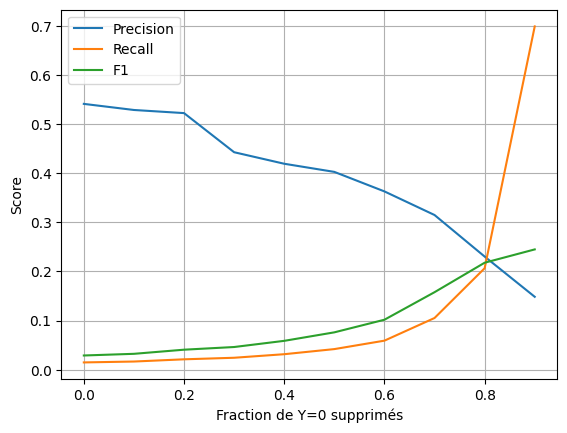

In [61]:
plt.plot(df["ratio_removed"], df["precision"], label="Precision")
plt.plot(df["ratio_removed"], df["recall"], label="Recall")
plt.plot(df["ratio_removed"], df["f1"], label="F1")
plt.xlabel("Fraction de Y=0 supprimés")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()


## Interprétation de l’impact de l’undersampling

Lorsque peu d’observations de la classe 0 sont supprimées, le modèle conserve une **précision élevée**, mais détecte très peu de réadmissions, comme le montre le **recall très faible**. Le modèle reste alors fortement biaisé vers la classe majoritaire.

À mesure que la proportion de la classe majoritaire supprimée augmente, le **recall progresse fortement**, indiquant que le modèle devient de plus en plus sensible à la classe minoritaire. Cette amélioration se fait cependant au prix d’une **baisse marquée de la précision**, traduisant une augmentation du nombre de faux positifs.

# 2.4) SVM Linéaire

Le SVM linéaire a été testé comme alternative à la régression logistique afin d’évaluer si une autre approche linéaire, basée sur la maximisation de la marge, pouvait améliorer la séparation entre les classes dans un contexte de fort déséquilibre.

Contrairement à la régression logistique, qui optimise une fonction de vraisemblance, le SVM cherche à maximiser la marge entre les observations des deux classes.

Enfin, le choix d’un **SVM linéaire** (plutôt qu’un noyau non linéaire) permet de conserver une complexité maîtrisée et des temps de calcul raisonnables.

In [68]:
svm = LinearSVC(
    class_weight="balanced",
    max_iter=5000,
    dual=False,       
    random_state=42
)

param_grid = [
    {
        "C": [0.001, 0.01, 0.1, 1, 10],
        "penalty": ["l2"],
        "loss": ["hinge", "squared_hinge"]
    },
    {
        "C": [0.001, 0.01, 0.1, 1, 10],
        "penalty": ["l1"],
        "loss": ["squared_hinge"]
    }
]

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_encoded, Y_train)

print("Best parameters :", grid_search.best_params_)
print(f"Best CV F1      : {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 15 candidates, totalling 75 fits


/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
25 fits failed out of a total of 75.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/violetteseptier/Desktop/applied/applied/

Best parameters : {'C': 0.01, 'loss': 'squared_hinge', 'penalty': 'l1'}
Best CV F1      : 0.2684


In [71]:
svm_linear = LinearSVC(
    C=0.01,
    penalty="l1",
    loss="squared_hinge",
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

svm_linear.fit(X_train_encoded, Y_train)

LinearSVC(C=0.01, class_weight='balanced', max_iter=5000, penalty='l1',
          random_state=42)

/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(



===== Linear SVM (C=0.1) vs Logistic Regression (ElasticNet) — TEST =====

             Linear SVM (C=0.1)  Logistic Regression (ElasticNet)       Δ
ROC_AUC                  0.6511                            0.6522 -0.0011
PR_AUC                   0.2005                            0.2019 -0.0013
Recall_1                 0.5359                            0.5364 -0.0005
Precision_1              0.1746                            0.1766 -0.0020
F1_1                     0.2634                            0.2658 -0.0023


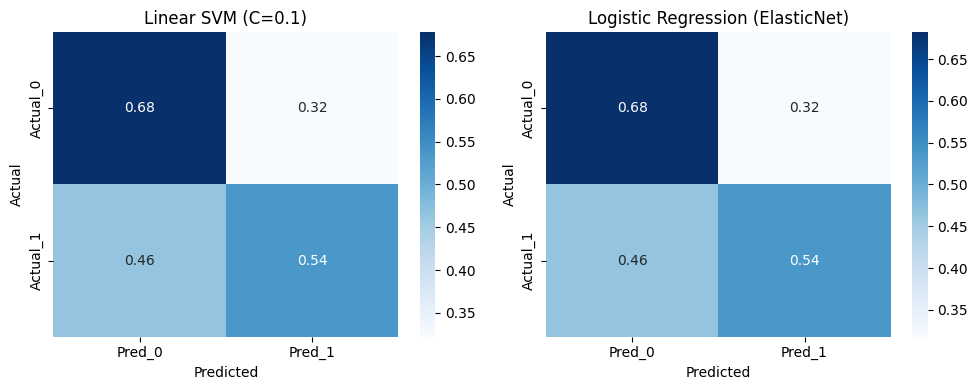

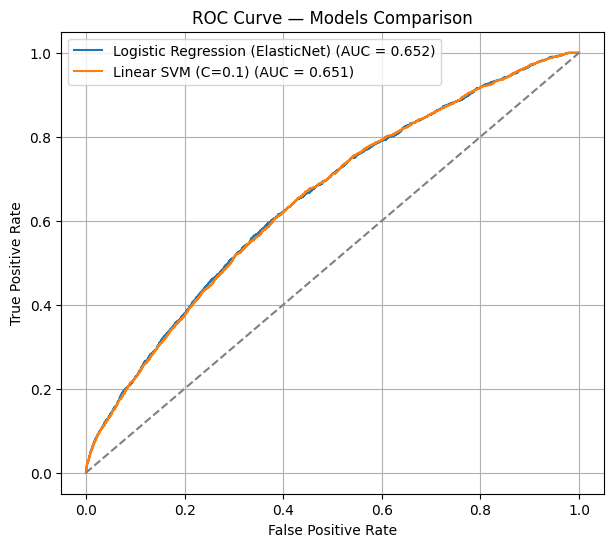

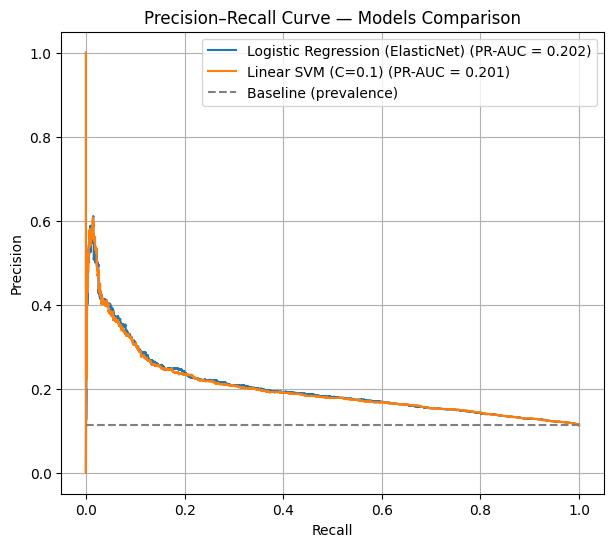

In [72]:
y_proba_test_svm = svm_linear.decision_function(X_test_encoded)
y_pred_test_svm = (y_proba_test_svm >= 0).astype(int)

metrics_comparison(
    Y_test,
    y_pred_test_svm,
    y_proba_test_svm,
    y_pred_test_logit,
    y_proba_test_logit,
    benchmark_name="Logistic Regression (ElasticNet)",
    model_name="Linear SVM (C=0.1)"
)

plot_confusion_matrices(
    Y_test,
    y_pred_test_svm,
    y_pred_test_logit,
    normalize="true",
    model_names=("Linear SVM (C=0.1)", "Logistic Regression (ElasticNet)")
)

plot_roc_comparison(
    Y_test,
    {
        "Logistic Regression (ElasticNet)": y_proba_test_logit,
        "Linear SVM (C=0.1)": y_proba_test_svm
    },
    title="ROC Curve — Models Comparison"
)

plot_pr_comparison(
    Y_test,
    {
        
        "Logistic Regression (ElasticNet)": y_proba_test_logit,
        "Linear SVM (C=0.1)": y_proba_test_svm
    },
    title="Precision–Recall Curve — Models Comparison"
)


### Conclusion
Le Linear SVM et la régression logistique avec Elastic Net offrent des performances très similaires sur ce problème.  
Dans ce contexte, le choix entre les deux modèles peut davantage reposer sur des critères pratiques que sur la performance brute, tels que l’interprétabilité, la facilité de calibration des probabilités ou l’intégration dans un pipeline existant.  
La régression logistique conserve notamment un avantage en termes d’interprétation et d’analyse des coefficients, tandis que le Linear SVM ne montre pas de gain significatif de performance justifiant sa complexité supplémentaire.


# 2.5) Descent de gradient stochastique

Selon la fonction de perte choisie, le SGD peut reproduire le comportement d’un logit (`log_loss`) ou d’un SVM linéaire (`hinge`), tout en offrant une plus grande flexibilité dans l’optimisation.

Contrairement aux implémentations classiques du logit et du SVM, qui reposent sur des solveurs spécifiques, le SGD optimise directement la fonction de perte par descente de gradient stochastique. Cette approche peut améliorer la convergence et la robustesse dans des contextes de grande dimension, notamment en présence de nombreuses variables issues de l’encodage et de corrélations entre features.

Le SGD permet également une exploration plus fine des compromis biais–variance grâce au réglage conjoint du taux de régularisation (`alpha`) et du mélange L1/L2 (`elasticnet`). Cela en fait un cadre plus général, capable d’adapter le niveau de régularisation aux spécificités des données, là où le logit et le SVM sont plus contraints dans leur paramétrisation.

In [73]:
sgd = SGDClassifier(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

param_distributions = [


    # L2 / L1

    {
        "loss": ["log_loss", "hinge", "modified_huber"],
        "penalty": ["l2", "l1"],
        "alpha": loguniform(1e-5, 1e-2),
        "tol": loguniform(1e-4, 1e-2)
    },

    # ElasticNet (l1_ratio requis)
    {
        "loss": ["log_loss", "hinge", "modified_huber"],
        "penalty": ["elasticnet"],
        "alpha": loguniform(1e-5, 1e-2),
        "tol": loguniform(1e-4, 1e-2),
        "l1_ratio": uniform(0.1, 0.8)
    }
]


random_search = RandomizedSearchCV(
    estimator=sgd,
    param_distributions=param_distributions,
    n_iter=100,              
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_encoded, Y_train)


print("Best parameters :", random_search.best_params_)
print(f"Best CV F1      : {random_search.best_score_:.4f}")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters : {'alpha': 0.0007039637468468568, 'l1_ratio': 0.6080749206941151, 'loss': 'hinge', 'penalty': 'elasticnet', 'tol': 0.00033249662907218827}
Best CV F1      : 0.2674


/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(



===== SGD Classifier (ElasticNet) vs Logistic Regression (ElasticNet) — TEST =====

             SGD Classifier (ElasticNet)  Logistic Regression (ElasticNet)       Δ
ROC_AUC                           0.6411                            0.6522 -0.0110
PR_AUC                            0.1936                            0.2019 -0.0083
Recall_1                          0.3028                            0.5364 -0.2336
Precision_1                       0.2002                            0.1766  0.0235
F1_1                              0.2410                            0.2658 -0.0247


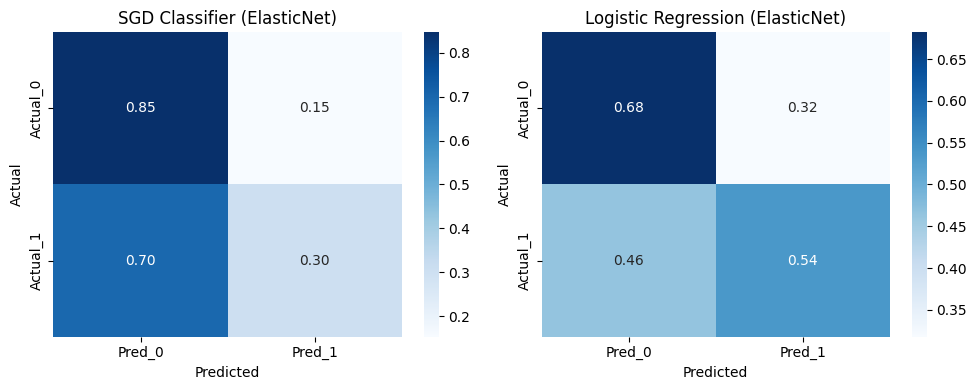

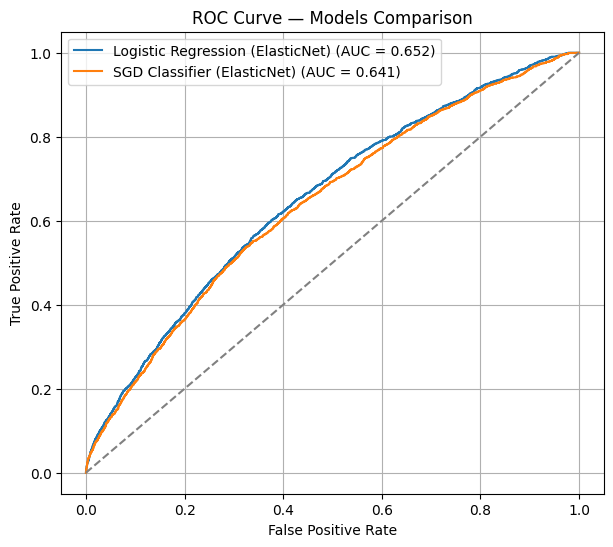

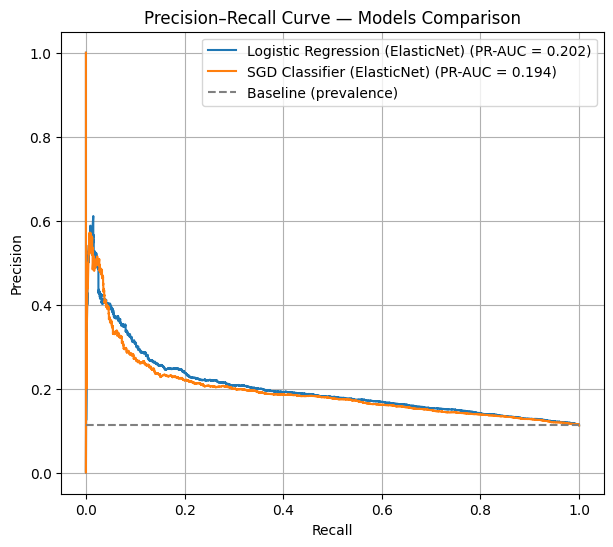

In [75]:
sdg = SGDClassifier(
    max_iter=3000,
    class_weight="balanced",
    random_state=42,
    loss="hinge",
    penalty="elasticnet",
    l1_ratio=0.6080749206941151,
    alpha=0.0007039637468468568,
    tol=0.00033249662907218827
)

sgd.fit(X_train_encoded, Y_train)


y_proba_test_sgd = sgd.decision_function(X_test_encoded)
y_pred_test_sgd = (y_proba_test_sgd >= 0).astype(int)

metrics_comparison(
    Y_test,
    y_pred_test_sgd,
    y_proba_test_sgd,
    y_pred_test_logit,
    y_proba_test_logit,
    benchmark_name="Logistic Regression (ElasticNet)",
    model_name="SGD Classifier (ElasticNet)"
)

plot_confusion_matrices(
    Y_test,
    y_pred_test_sgd,
    y_pred_test_logit,
    normalize="true",
    model_names=("SGD Classifier (ElasticNet)", "Logistic Regression (ElasticNet)")
)

plot_roc_comparison(
    Y_test,
    {
        "Logistic Regression (ElasticNet)": y_proba_test_logit,
        "SGD Classifier (ElasticNet)": y_proba_test_sgd
    },
    title="ROC Curve — Models Comparison"
)

plot_pr_comparison(
    Y_test,
    {
        "Logistic Regression (ElasticNet)": y_proba_test_logit,
        "SGD Classifier (ElasticNet)": y_proba_test_sgd
    },
    title="Precision–Recall Curve — Models Comparison"
)

## Interprétation des performances : SGDClassifier vs Régression Logistique (Elastic Net)

Les résultats montrent que le SGDClassifier, présente des performances légèrement inférieures, en particulier sur la classe minoritaire.

### Analyse des courbes Precision–Recall
La courbe Precision–Recall du SGDClassifier se situe légèrement en dessous de celle de la régression logistique sur l’ensemble des niveaux de recall. Le **PR-AUC plus faible** confirme que, pour un même niveau de rappel, le SGD offre en moyenne une précision légèrement inférieure.

Cela suggère que le compromis précision–rappel est moins favorable pour le SGD, en particulier dans les zones de recall modéré à élevé, qui sont pourtant les plus pertinentes dans un contexte de classes déséquilibrées.


Le SGDClassifier n’apporte pas d’amélioration par rapport à la régression logistique avec Elastic Net. Malgré sa flexibilité et sa capacité à reproduire différents modèles linéaires, il semble moins bien calibré pour la détection fine de la classe minoritaire dans ce contexte.

La régression logistique reste un choix plus robuste et plus fiable, tout en conservant une interprétabilité supérieure.


# Modèles ensembliste

## 2.6) Random Forest

Après l’exploration de plusieurs modèles linéaires, l’utilisation d’un **Random Forest** permet d’introduire de la **non-linéarité**.

Contrairement aux modèles linéaires, le Random Forest est capable de capturer automatiquement des **interactions entre variables** ainsi que des **effets seuils**, qui sont fréquents dans des données cliniques (par exemple, l’effet combiné de l’âge, du nombre de diagnostics et de la durée d’hospitalisation). Ces relations sont difficiles, voire impossibles, à modéliser correctement avec une frontière de décision linéaire.

Le Random Forest repose sur un ensemble d’arbres de décision entraînés sur des sous-échantillons aléatoires des données et des variables. Ce mécanisme permet de **réduire la variance**, d’améliorer la robustesse du modèle et de limiter le surapprentissage, tout en conservant de bonnes performances sur des données hétérogènes.



In [76]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "max_depth": [5, 10, 15, 20],
    "max_features": [0.3, 0.5, 1.0, "sqrt", "log2"],
    "min_samples_split": [2, 5, 10, 20],
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,                  
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train_encoded, Y_train)

print("Best params:", search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'min_samples_split': 10, 'max_features': 0.3, 'max_depth': 10}



===== Random Forest vs Logistic Regression (ElasticNet) — TEST =====

             Random Forest  Logistic Regression (ElasticNet)       Δ
ROC_AUC             0.6632                            0.6522  0.0110
PR_AUC              0.2138                            0.2019  0.0119
Recall_1            0.5522                            0.5364  0.0158
Precision_1         0.1793                            0.1766  0.0026
F1_1                0.2707                            0.2658  0.0049


/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


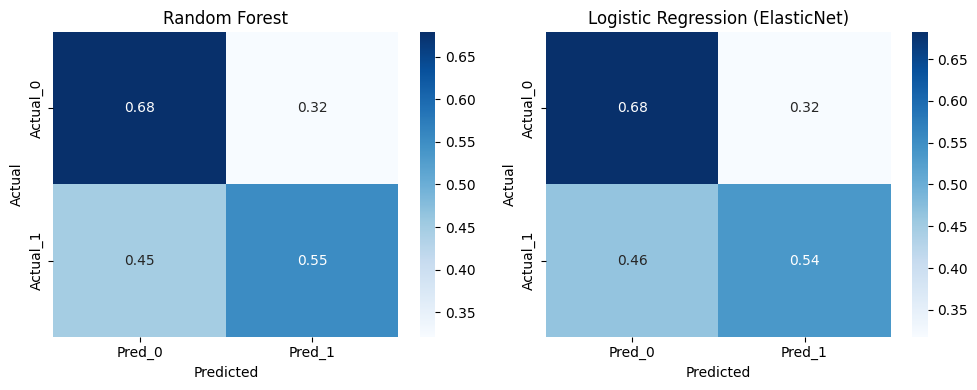

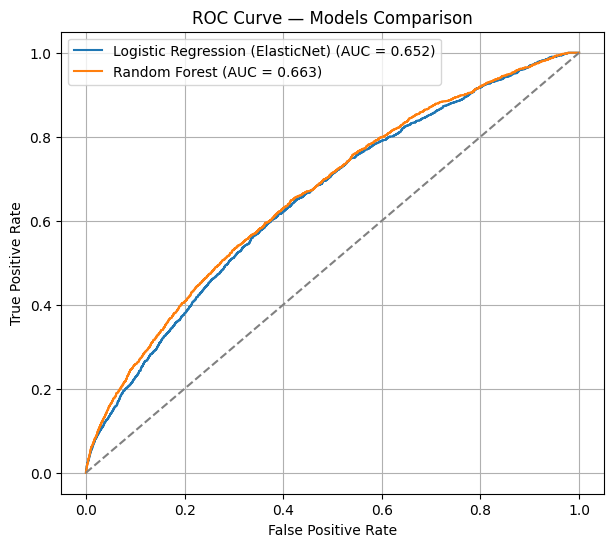

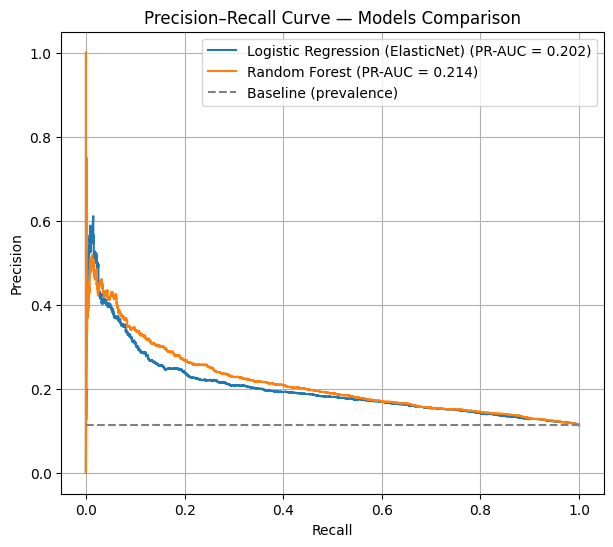

In [78]:
RF = RandomForestClassifier(
    n_estimators=300,
    max_features=0.3,
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)



RF.fit(X_train_encoded, Y_train)

y_proba_test_rf = RF.predict_proba(X_test_encoded)[:, 1]
y_pred_test_rf = (y_proba_test_rf >= 0.5).astype(int)

metrics_rf = metrics_comparison(
    Y_test,
    y_pred_test_rf,
    y_proba_test_rf,
    y_pred_test_logit,
    y_proba_test_logit,
    benchmark_name="Logistic Regression (ElasticNet)",
    model_name="Random Forest"
)

plot_confusion_matrices(
    Y_test,
    y_pred_test_rf,
    y_pred_test_logit,
    normalize="true",
    model_names=("Random Forest", "Logistic Regression (ElasticNet)")
)

plot_roc_comparison(
    Y_test,
    {
        "Logistic Regression (ElasticNet)": y_proba_test_logit,
        "Random Forest": y_proba_test_rf
    },
    title="ROC Curve — Models Comparison"
)

plot_pr_comparison(
    Y_test,
    {
        "Logistic Regression (ElasticNet)": y_proba_test_logit,
        "Random Forest": y_proba_test_rf
    },
    title="Precision–Recall Curve — Models Comparison"
)




L’introduction du **Random Forest** conduit à une **amélioration cohérente mais modérée** des performances par rapport à la régression logistique.


### Détection de la classe minoritaire (PR-AUC et Recall)
Les gains sont plus visibles sur les métriques centrées sur la classe positive :
- Le **recall** est légèrement supérieur, traduisant une meilleure détection des réadmissions.
- Le **PR-AUC** progresse également, ce qui est particulièrement pertinent dans un contexte de **fort déséquilibre des classes**.

Les courbes précision–recall montrent que le Random Forest maintient une précision légèrement plus élevée pour un même niveau de recall sur une large plage de seuils.

### Interprétation globale
Le Random Forest apporte un **gain réel mais progressif** :
- Il exploite mieux la complexité des données grâce à sa nature non linéaire.
- Il reste toutefois proche de la régression logistique en termes de performances globales, ce qui suggère que la structure du problème est en grande partie **linéairement exploitable**.


Best threshold (RF): 0.59


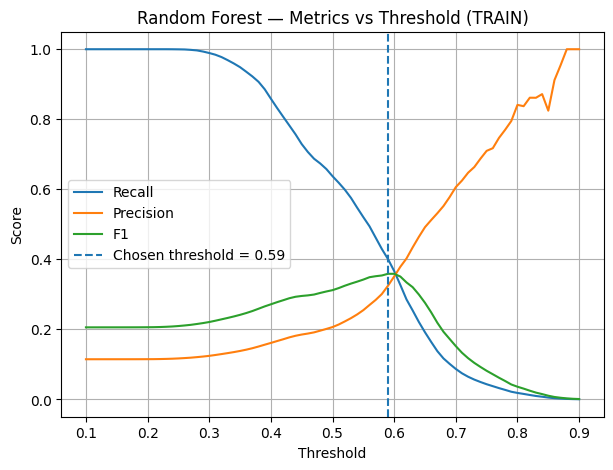


===== Random Forest – Optimized Threshold vs Random Forest (threshold = 0.5) — TEST =====

             Random Forest – Optimized Threshold  Random Forest (threshold = 0.5)       Δ
ROC_AUC                                   0.6632                           0.6632  0.0000
PR_AUC                                    0.2138                           0.2138  0.0000
Recall_1                                  0.2829                           0.5522 -0.2693
Precision_1                               0.2354                           0.1793  0.0562
F1_1                                      0.2570                           0.2707 -0.0137


/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


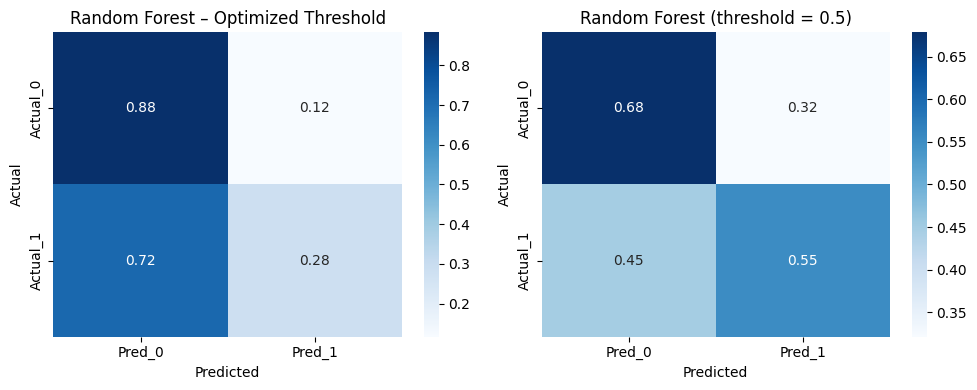

In [110]:
# on test plusieurs seuil 


y_proba_train_rf = RF.predict_proba(X_train_encoded)[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)

results_thresholds_rf = []

for t in thresholds:
    y_pred_train_rf = (y_proba_train_rf >= t).astype(int)

    results_thresholds_rf.append({
        "threshold": t,
        "recall": recall_score(Y_train, y_pred_train_rf),
        "precision": precision_score(Y_train, y_pred_train_rf),
        "f1": f1_score(Y_train, y_pred_train_rf),
        "pr_auc": average_precision_score(Y_train, y_proba_train_rf)
    })


thresholds_df_rf = pd.DataFrame(results_thresholds_rf)

# Meilleurs seuils selon le F1-score
thresholds_df_rf.sort_values("f1", ascending=False).head(10)

# Seuil choisi (exemple : meilleur F1)
best_threshold_rf = thresholds_df_rf.loc[
    thresholds_df_rf["f1"].idxmax(), "threshold"
]

print(f"Best threshold (RF): {best_threshold_rf:.2f}")

# Graph

plt.figure(figsize=(7, 5))
plt.plot(thresholds_df_rf["threshold"], thresholds_df_rf["recall"], label="Recall")
plt.plot(thresholds_df_rf["threshold"], thresholds_df_rf["precision"], label="Precision")
plt.plot(thresholds_df_rf["threshold"], thresholds_df_rf["f1"], label="F1")
plt.axvline(
    best_threshold_rf,
    linestyle="--",
    label=f"Chosen threshold = {best_threshold_rf:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Random Forest — Metrics vs Threshold (TRAIN)")
plt.legend()
plt.grid(True)
plt.show()


# On applique le seuil au test

y_proba_test_rf_opt = RF.predict_proba(X_test_encoded)[:, 1]

y_pred_test_rf_opt = (y_proba_test_rf_opt >= best_threshold_rf).astype(int)



metrics_comparison(
    Y_test,
    y_pred_test_rf_opt,
    y_proba_test_rf_opt,
    y_pred_test_rf,
    y_proba_test_rf,
    model_name="Random Forest – Optimized Threshold",
    benchmark_name="Random Forest (threshold = 0.5)"
)

plot_confusion_matrices(
    Y_test,
    y_pred_test_rf_opt,
    y_pred_test_rf,
    normalize="true",
    model_names=(
        "Random Forest – Optimized Threshold",
        "Random Forest (threshold = 0.5)"
    )
)


# 2.7) LIGHTGBM

LightGBM repose sur une approche de **gradient boosting d’arbres de décision**, ce qui lui permet de **capturer des non-linéarités et des interactions entre variables**.

Par rapport au Random Forest, LightGBM construit les arbres de manière **séquentielle**, chaque nouvel arbre cherchant à corriger les erreurs des précédents. Cette stratégie permet généralement une **meilleure capacité de discrimination**, notamment sur la classe minoritaire.

In [79]:
base_lgb = lgb.LGBMClassifier(
     objective="binary",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


param_dist = {
    "n_estimators": randint(100, 1200),
    "learning_rate": loguniform(1e-3, 0.3),
    "num_leaves": randint(15, 80),
    "max_depth": randint(-1, 16),
    "min_child_samples": randint(5, 100),
    "subsample": uniform(0.6, 0.4),          
    "colsample_bytree": uniform(0.6, 0.4),   
    "reg_alpha": loguniform(1e-4, 10),
    "reg_lambda": loguniform(1e-4, 10)
}



search_lgb = RandomizedSearchCV(
    estimator=base_lgb,
    param_distributions=param_dist,
    n_iter=20,                   
    scoring="f1",  
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)


search_lgb.fit(X_train_encoded, Y_train)

print("Best params:", search_lgb.best_params_) 



Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 7082, number of negative: 55668
[LightGBM] [Info] Number of positive: 7083, number of negative: 55667
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 7083, number of negative: 55667
[LightGBM] [Info] Number of positive: 7082, number of negative: 55667
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 7082, number of negative: 55667
[LightGBM] [Info] Number of 

/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 8853, number of negative: 69584
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 386
[LightGBM] [Info] Number of data points in the train set: 78437, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 8853, number of negative: 69584
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 386
[LightGBM] [Info] Number of data points in the train set: 78437, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

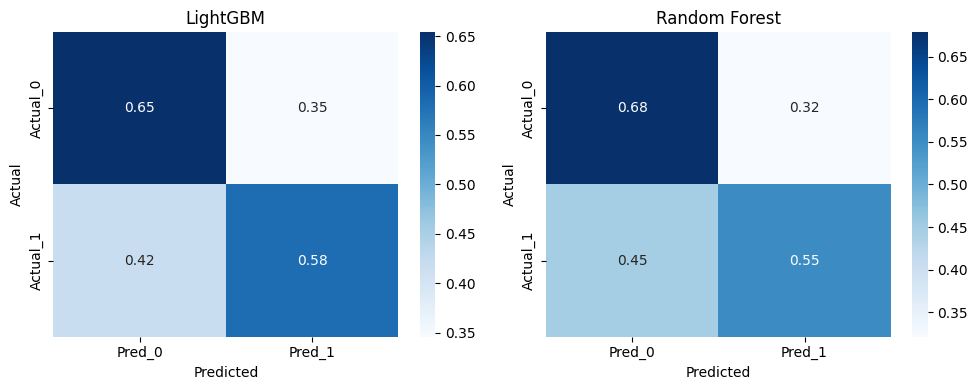

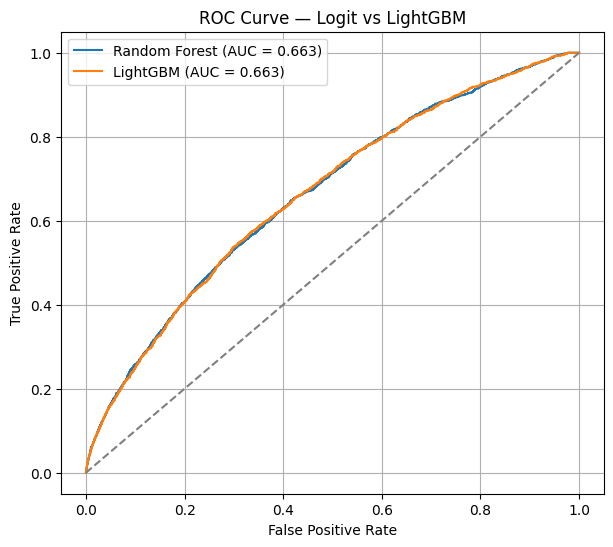

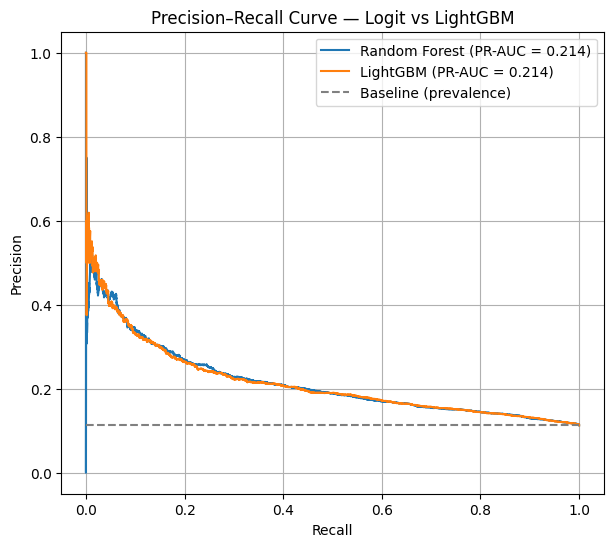

In [111]:
lgbm = lgb.LGBMClassifier(
    objective="binary",
    class_weight="balanced",  
    n_estimators=851,
    learning_rate=0.03683818397185092,
    max_depth=4,                
    num_leaves=30,               
    min_child_samples=90,
    subsample=0.6746074041599417,
    colsample_bytree=0.7471132530877013,
    reg_alpha=1.5014555442537663,
    reg_lambda=0.004016986062226069,
    random_state=42,
    n_jobs=-1
)




lgbm.fit(X_train_encoded, Y_train)

y_proba_test_lgb = lgbm.predict_proba(X_test_encoded)[:, 1]
y_pred_test_lgb = (y_proba_test_lgb >= 0.5).astype(int)

metrics_comparison(
    Y_test,
    y_pred_test_lgb,
    y_proba_test_lgb,
    y_pred_test_rf,
    y_proba_test_rf,
    benchmark_name="Random Forest",
    
    model_name="LightGBM"
)

plot_confusion_matrices(
    Y_test,
    y_pred_test_lgb,
    y_pred_test_rf,
    normalize="true",
    model_names=("LightGBM", "Random Forest")
)

plot_roc_comparison(
    y_true=Y_test,
    y_proba_dict={
        "Random Forest": y_proba_test_rf,
        "LightGBM": y_proba_test_lgb
    },
    title="ROC Curve — Logit vs LightGBM"
)


plot_pr_comparison(
    y_true=Y_test,
    y_proba_dict={
        "Random Forest": y_proba_test_rf,
        "LightGBM": y_proba_test_lgb
    },
    title="Precision–Recall Curve — Logit vs LightGBM"
)

### Analyse comparative — LightGBM vs Random Forest

Les résultats montrent que **LightGBM** apporte une **amélioration sur la détection de la classe minoritaire**, tout en conservant un niveau global de performance proche de celui du Random Forest.


- **LightGBM est préférable** si l’objectif est de **maximiser la détection des réadmissions**, quitte à générer plus de faux positifs.




# 2.8) HistGradientBoostingClassifier

Le **HistGradientBoostingClassifier** est utilisé car il **gère nativement les variables catégorielles**, sans avoir recours à un encodage one-hot. Cela permet de conserver l’information portée par les catégories tout en évitant l’augmentation artificielle du nombre de variables.


In [ ]:


X_train_bis, X_test_bis, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

 #Bien que HistGradientBoosting prenne en charge les variables catégorielles de manière native, celles-ci doivent être encodées en entiers et explicitement 
 # indiquées pour éviter toute interprétation numérique ordinale.

categorical_cols = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "diag_1",
    "diag_2",
    "diag_3",
    "metformin",
    "repaglinide",
    "glimepiride",
    "glipizide",
    "glyburide",
    "pioglitazone",
    "rosiglitazone",
    "insulin",
    "change",
    "diabetesMed"
]


ordinal_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_enc = X_train_bis.copy()
X_test_enc = X_test_bis.copy()

X_train_enc[categorical_cols] = ordinal_encoder.fit_transform(
    X_train_bis[categorical_cols]
)

X_test_enc[categorical_cols] = ordinal_encoder.transform(
    X_test_bis[categorical_cols]
)

categorical_mask = [
    col in categorical_cols
    for col in X_train_enc.columns
]



In [124]:


hgb = HistGradientBoostingClassifier(
    class_weight="balanced",
    categorical_features=categorical_mask,
    random_state=42
)

param_distributions = {
    "learning_rate": loguniform(0.01, 0.1),
    "max_depth": randint(3, 10),
    "max_leaf_nodes": randint(15, 63),
    "min_samples_leaf": randint(10, 50),
    "l2_regularization": loguniform(1e-4, 1)
}


random_search = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=param_distributions,
    n_iter=40,          
    scoring="f1",       
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)


random_search.fit(X_train_enc, Y_train)

print("Best params:", random_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


KeyboardInterrupt: 

In [ ]:
hgb = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.023322931283542653,
    max_leaf_nodes=48,
    min_samples_leaf=15,
    class_weight="balanced",
    l2_regularization=0.08182111518618412,
    categorical_features=categorical_mask,
    random_state=42
)



===== HistGradientBoosting vs LightGBM — TEST =====

             HistGradientBoosting  LightGBM       Δ
ROC_AUC                    0.6625    0.6632 -0.0007
PR_AUC                     0.2138    0.2142 -0.0004
Recall_1                   0.5879    0.5807  0.0072
Precision_1                0.1747    0.1758 -0.0011
F1_1                       0.2693    0.2699 -0.0006


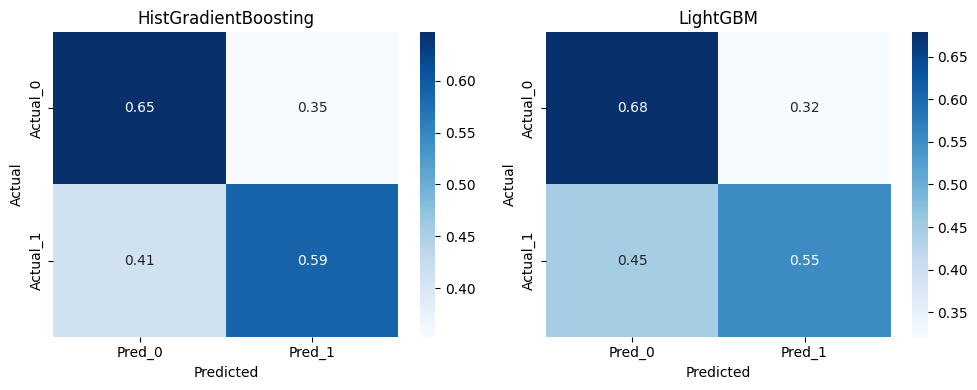

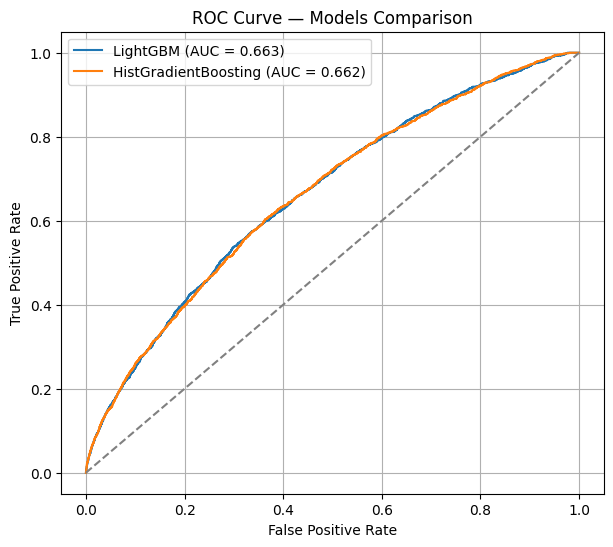

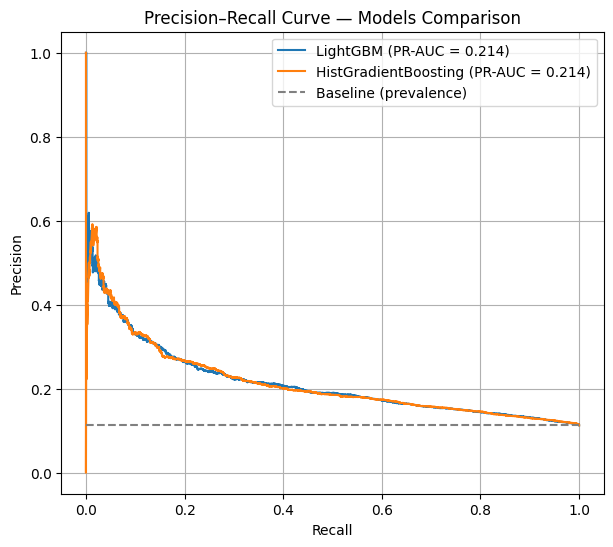

In [125]:
hgb.fit(X_train_enc, Y_train)

y_proba_test_hgb = hgb.predict_proba(X_test_enc)[:, 1]

y_proba_test_hgb = hgb.predict_proba(X_test_enc)[:, 1]
y_pred_test_hgb = (y_proba_test_hgb >= 0.5).astype(int)

metrics_comparison(
    Y_test,
    y_pred_test_hgb,
    y_proba_test_hgb,
    y_pred_test_lgb,
    y_proba_test_lgb,
    benchmark_name="LightGBM",

    model_name="HistGradientBoosting"
)

plot_confusion_matrices(
    Y_test,
    y_pred_test_hgb,
    y_pred_test_rf,
    normalize="true",
    model_names=("HistGradientBoosting", "LightGBM")
)

plot_roc_comparison(
    y_true=Y_test,
    y_proba_dict={
        "LightGBM": y_proba_test_lgb,
        "HistGradientBoosting": y_proba_test_hgb
    },
    title="ROC Curve — Models Comparison"
)

plot_pr_comparison(
    y_true=Y_test,
    y_proba_dict={
        "LightGBM": y_proba_test_lgb,
        "HistGradientBoosting": y_proba_test_hgb
    },
    title="Precision–Recall Curve — Models Comparison"
)




### Conclusion

HistGradientBoosting semble être un **meilleur compromis** que LightGBM.

Il est **plus simple à utiliser** (moins d’hyperparamètres, intégration directe dans scikit-learn, pas de OHE) tout en offrant des **performances très proches**. Surtout, il **détecte légèrement mieux la classe positive** (meilleur recall), ce qui est un point clé dans notre jeu.



# 2.9) Catboost

In [85]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)


categorical_cols = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "diag_1",
    "diag_2",
    "diag_3",
    "metformin",
    "repaglinide",
    "glimepiride",
    "glipizide",
    "glyburide",
    "pioglitazone",
    "rosiglitazone",
    "insulin",
    "change",
    "diabetesMed"
]

X_train_cat[categorical_cols] = X_train_cat[categorical_cols].astype(str)
X_test_cat[categorical_cols] = X_test_cat[categorical_cols].astype(str)

assert all(
    X_train_cat[categorical_cols].dtypes == "object"
), "Erreur : certaines variables catégorielles ne sont pas en string"

# Les variables catégorielles, y compris les variables binaires initialement codées numériquement, ont été explicitement converties en chaînes de caractères 
# et déclarées via le paramètre cat_features, afin de permettre à CatBoost de les traiter nativement comme des catégories sans encodage préalable.


In [86]:
n_pos = (y_train_cat == 1).sum()
n_neg = (y_train_cat == 0).sum()


total = n_pos + n_neg
class_weights = [
    total / (2 * n_neg),   
    total / (2 * n_pos)    
]


base_cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=False,
    class_weights=class_weights
)




param_dist_cat = {
    "depth": randint(3, 7),
    "learning_rate": loguniform(5e-3, 8e-2),
    "l2_leaf_reg": loguniform(1e-2, 5),
    "iterations": randint(80, 300),
    "border_count": randint(16, 64),

    "loss_function": [
        "Logloss",
        "Focal"
    ],
    "eval_metric": [
        "F1",
        "PRAUC"
    ]
}





search_cat = RandomizedSearchCV(
    estimator=base_cat,
    param_distributions=param_dist_cat,
    n_iter=20,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)


search_cat.fit(
    X_train_cat,
    y_train_cat,
    cat_features=categorical_cols
)

print("Best params:", search_cat.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
45 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/catboost/core.py", line 5131, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, sample_weight, None, None, None,

Best params: {'border_count': 42, 'depth': 5, 'eval_metric': 'F1', 'iterations': 249, 'l2_leaf_reg': 0.013364392600330292, 'learning_rate': 0.07438553360892036, 'loss_function': 'Logloss'}


0:	learn: 0.6326614	total: 22.2ms	remaining: 5.5s
100:	learn: 0.6317132	total: 2.05s	remaining: 3s
200:	learn: 0.6446568	total: 4.13s	remaining: 986ms
248:	learn: 0.6488538	total: 5.1s	remaining: 0us

===== CatBoost vs HistGradientBoosting — TEST =====

             CatBoost  HistGradientBoosting       Δ
ROC_AUC        0.6655                0.6625  0.0030
PR_AUC         0.2160                0.2138  0.0022
Recall_1       0.5933                0.5879  0.0054
Precision_1    0.1740                0.1747 -0.0006
F1_1           0.2691                0.2693 -0.0002


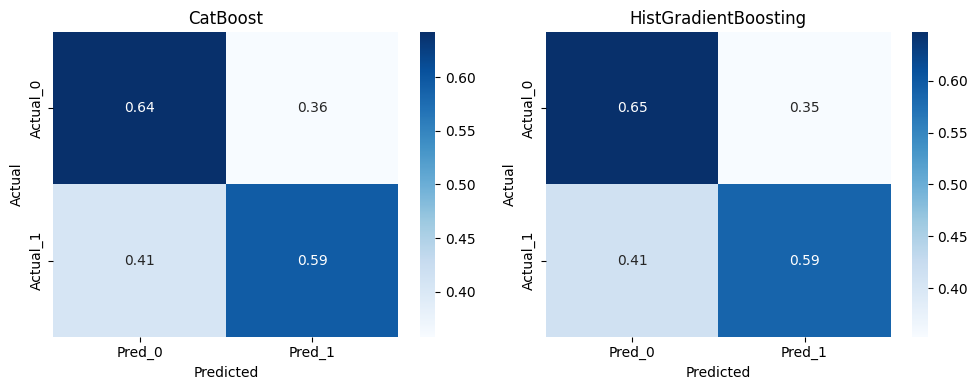

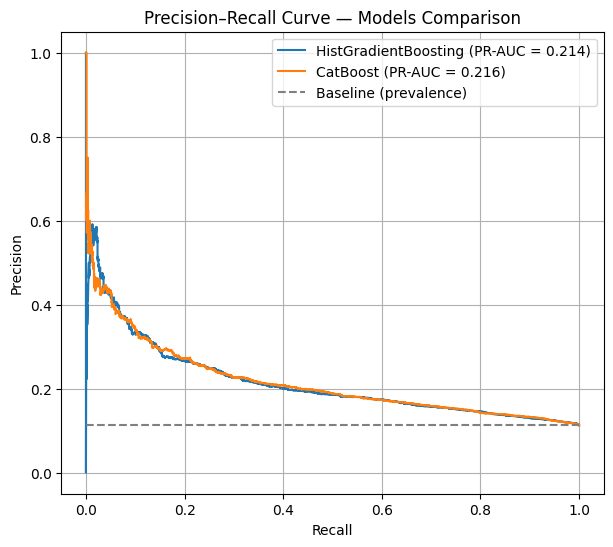

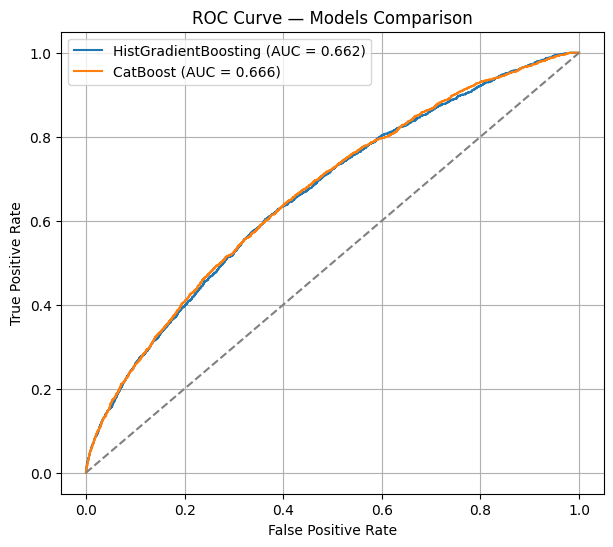

In [ ]:
# Calcul des poids de classes
n_pos = (y_train_cat == 1).sum()
n_neg = (y_train_cat == 0).sum()

class_weights = [
    n_pos / (n_pos + n_neg),   # poids classe 0
    n_neg / (n_pos + n_neg)    # poids classe 1
]

cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="F1",
    iterations=249,
    learning_rate=0.07438553360892036,
    depth=5,
    class_weights=class_weights,
    border_count=42,
    l2_leaf_reg=0.013364392600330292,
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=categorical_cols
)

y_proba_test_cat = cat_model.predict_proba(X_test_cat)[:, 1]
y_pred_test_cat = (y_proba_test_cat >= 0.5).astype(int)



metrics_comparison(
    y_test_cat,
    y_pred_test_cat,
    y_proba_test_cat,
    y_pred_test_hgb,
    y_proba_test_hgb,
    benchmark_name="HistGradientBoosting",
    model_name="CatBoost"
)

plot_confusion_matrices(
    y_test_cat,
    y_pred_test_cat,
    y_pred_test_hgb,
    normalize="true",
    model_names=("CatBoost", "HistGradientBoosting")
)

plot_pr_comparison(
    y_true=y_test_cat,
    y_proba_dict={
        "HistGradientBoosting": y_proba_test_hgb,
        "CatBoost": y_proba_test_cat
    },
    title="Precision–Recall Curve — Models Comparison"
)

plot_roc_comparison(
    y_true=y_test_cat,
    y_proba_dict={
        "HistGradientBoosting": y_proba_test_hgb,
        "CatBoost": y_proba_test_cat
    },
    title="ROC Curve — Models Comparison"
)



# 2.10) Réseaux neuronne

## MLP avec sklearn

In [88]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train_encoded, Y_train)


mlp = MLPClassifier(
    solver="adam",
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)

param_dist = {
    "hidden_layer_sizes": [
        (32, 16),
        (64, 32),
        (128, 64),
        (128, 64, 32)
    ],
    "activation": ["relu", "tanh"],
    "alpha": loguniform(1e-5, 1e-1),
    "learning_rate_init": loguniform(1e-4, 5e-2),
    "batch_size": randint(64, 257)
}

mlp = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

mlp.fit(X_under, y_under)

print("Best params:", mlp.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'activation': 'tanh', 'alpha': 3.077180271250682e-05, 'batch_size': 71, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.00029370138845625}


/Users/violetteseptier/Desktop/applied/applied/.venv/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(



===== Réseaux neuronne vs  — TEST =====

             Réseaux neuronne               Δ
ROC_AUC                0.6563  0.6625 -0.0062
PR_AUC                 0.2050  0.2138 -0.0088
Recall_1               0.6498  0.5879  0.0619
Precision_1            0.1657  0.1747 -0.0090
F1_1                   0.2640  0.2693 -0.0053


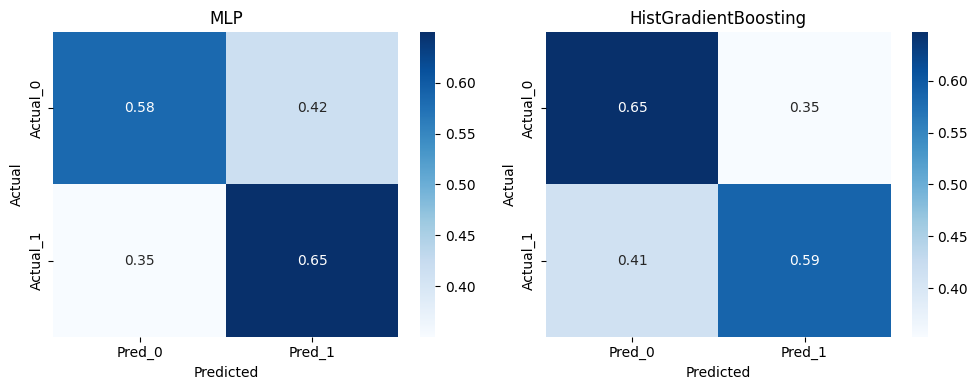

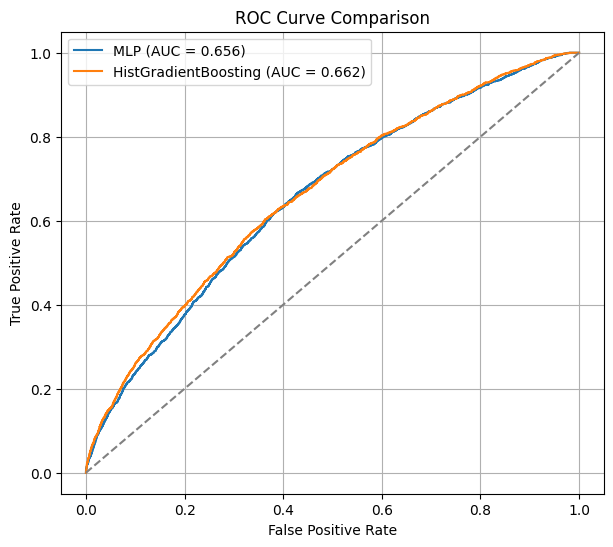

In [127]:
rus = RandomUnderSampler(random_state=42)
X_train_bal, Y_train_bal = rus.fit_resample(X_train_encoded, Y_train)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="tanh",
    solver="adam",
    alpha=3.077180271250682e-05,
    batch_size=71,
    learning_rate_init=0.00029370138845625,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)

mlp.fit(X_train_bal, Y_train_bal)

y_proba_test_mlp = mlp.predict_proba(X_test_encoded)[:, 1]
y_pred_test_mlp = (y_proba_test_mlp >= 0.5).astype(int)


metrics_comparison(
    Y_test,
    y_pred_test_mlp,
    y_proba_test_mlp,
    y_pred_test_hgb,
    y_proba_test_hgb,
    benchmark_name="",
    model_name="Réseaux neuronne"
)

plot_confusion_matrices(
    Y_test,
    y_pred_test_mlp,
    y_pred_test_hgb,
    normalize="true",
    model_names=("MLP", "HistGradientBoosting")
)

plot_roc_comparison(
    y_true=Y_test,
    y_proba_dict={
        "MLP": y_proba_test_mlp,
        "HistGradientBoosting": y_proba_test_hgb
    }
)

HistGradientBoosting apparaît comme un choix plus fiable par défaut, tandis que le MLP peut être pertinent si la priorité absolue est de maximiser la détection des positifs.


# MLP avec Pytorch

In [90]:
# Voir autre fichier car demander trop de RAM pour ce notebook.

# 3) Interprétation Modélé

In [91]:
def extract_model_coefficients(model, model_name, feature_names):
    """Coefficients pour modèles linéaires"""

    if not hasattr(model, "coef_"):
        return None

    coef = model.coef_
    if coef.ndim == 2:
        coef = coef[0]

    if len(coef) != len(feature_names):
        raise ValueError(
            f"[{model_name}] {len(coef)} coef ≠ {len(feature_names)} features"
        )

    df = pd.DataFrame({
        "model": model_name,
        "feature": feature_names,
        "coef": coef,
        "abs_coef": np.abs(coef),
        "effect": np.where(
            coef > 0,
            "Augmente P(Y=1)",
            "Diminue P(Y=1)"
        )
    })

    df["importance_norm"] = df["abs_coef"] / df["abs_coef"].sum()
    return df.sort_values("abs_coef", ascending=False)


In [92]:
def extract_feature_importance(model, model_name, feature_names):
    """Feature importance pour modèles à arbres"""

    if not hasattr(model, "feature_importances_"):
        return None

    if len(model.feature_importances_) != len(feature_names):
        raise ValueError(
            f"[{model_name}] importance ≠ features"
        )

    return (
        pd.DataFrame({
            "model": model_name,
            "feature": feature_names,
            "importance": model.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


In [93]:
models = {
    "RandomForest": RF,
    "Logistic Regression (ElasticNet)": best_model,
    "Linear SVM": svm_linear,
    "Lightgbm" : lgbm,
    "HistGradientBoostingClassifier": hgb,
    "CatBoost": cat_model,
    "Réseaux Neuronnes ": mlp, 
     
}

In [94]:
feature_names = X_train_encoded.columns


In [95]:
coef_tables = []

for name, model in models.items():

    df_coef = extract_model_coefficients(
        model=model,
        model_name=name,
        feature_names=feature_names
    )

    if df_coef is None:
        print(f" {name} : pas de coefficients")
        continue

    coef_tables.append(df_coef)


 RandomForest : pas de coefficients
 Lightgbm : pas de coefficients
 HistGradientBoostingClassifier : pas de coefficients
 CatBoost : pas de coefficients
 Réseaux Neuronnes  : pas de coefficients


In [96]:
coef_summary = pd.concat(coef_tables, axis=0).reset_index(drop=True)
coef_summary


,model,feature,coef,abs_coef,effect,importance_norm
0,Logistic Regression (ElasticNet),cat__discharge_disposition_id_Décès,-1.561894,1.561894,Diminue P(Y=1),0.382016
1,Logistic Regression (ElasticNet),cat__discharge_disposition_id_Établissement de...,0.367287,0.367287,Augmente P(Y=1),0.089833
2,Logistic Regression (ElasticNet),num__number_inpatient,0.362735,0.362735,Augmente P(Y=1),0.088720
3,Logistic Regression (ElasticNet),icd_140_239,0.172711,0.172711,Augmente P(Y=1),0.042242
4,Logistic Regression (ElasticNet),cat__discharge_disposition_id_Domicile,-0.170843,0.170843,Diminue P(Y=1),0.041786
...,...,...,...,...,...,...
91,Linear SVM,icd_740_759,0.000000,0.000000,Diminue P(Y=1),0.000000
92,Linear SVM,icd_760_779,0.000000,0.000000,Diminue P(Y=1),0.000000
93,Linear SVM,icd_280_289,0.000000,0.000000,Diminue P(Y=1),0.000000
94,Linear SVM,icd_V01_V86,0.000000,0.000000,Diminue P(Y=1),0.000000


### Modèle facile à interprèter grace au coef (on ne prends pas SDG qui donne des résltats sans plus)

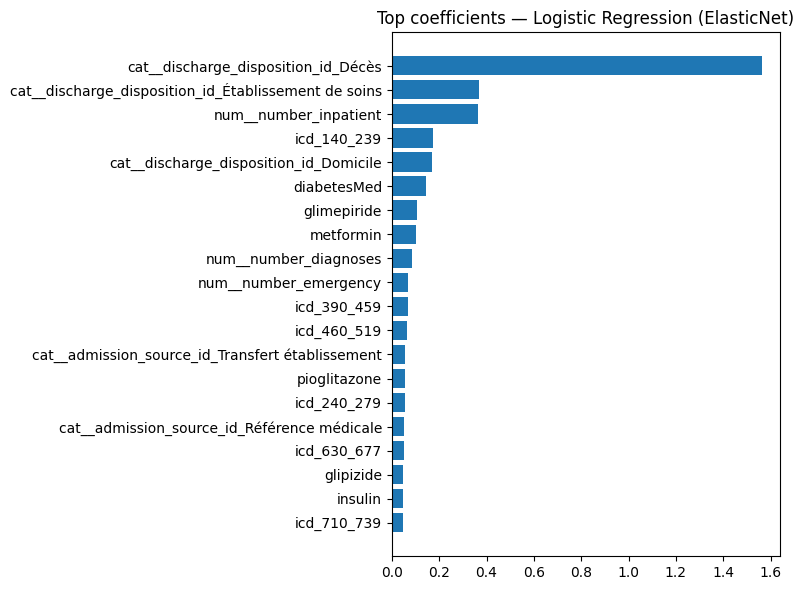

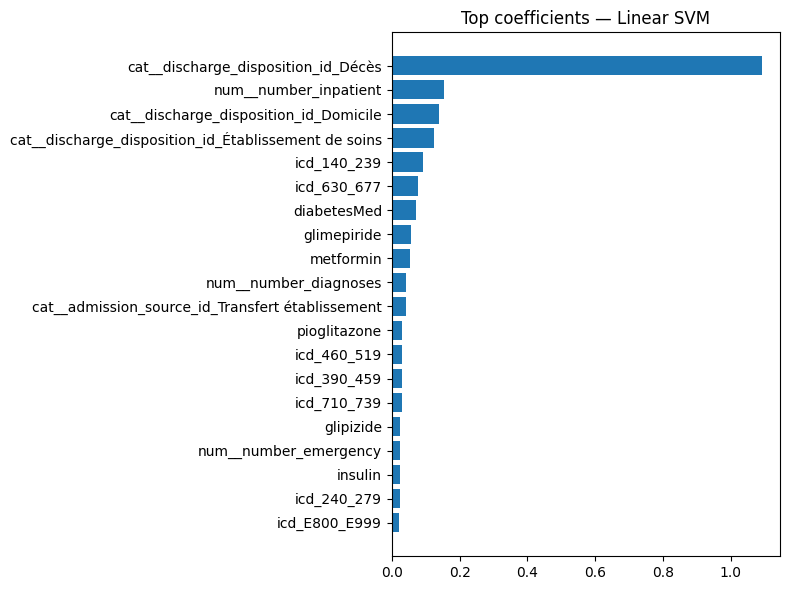

In [97]:
for model_name in coef_summary["model"].unique():

    df_plot = (
        coef_summary[coef_summary["model"] == model_name]
        .sort_values("abs_coef", ascending=False)
        .head(20)
    )

    plt.figure(figsize=(8,6))
    plt.barh(df_plot["feature"], df_plot["abs_coef"])
    plt.gca().invert_yaxis()
    plt.title(f"Top coefficients — {model_name}")
    plt.tight_layout()
    plt.show()


### On passe à des modèles plus compliqué à interpréter, pour Random forest, Lightbm on peut utiliser feature_importances_, qui nous permet d'interpréter des arbres. 
### voir doc pour pus d'info

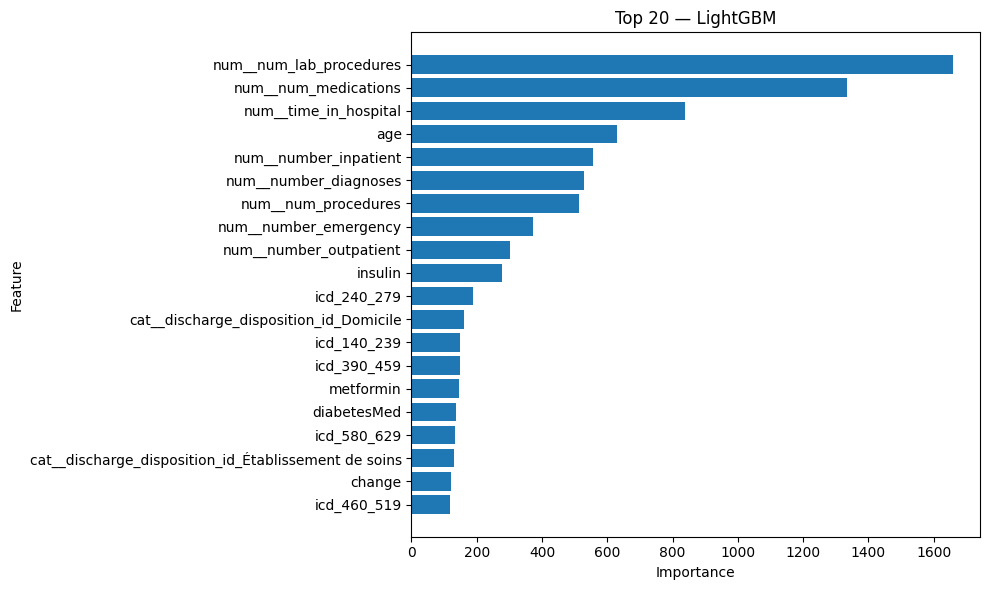

In [98]:
LG = extract_feature_importance(
    model=lgbm,
    model_name="Lightgbm",
    feature_names=feature_names
)

top20 = LG.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["feature"], top20["importance"])
plt.gca().invert_yaxis()       
plt.title("Top 20 — LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


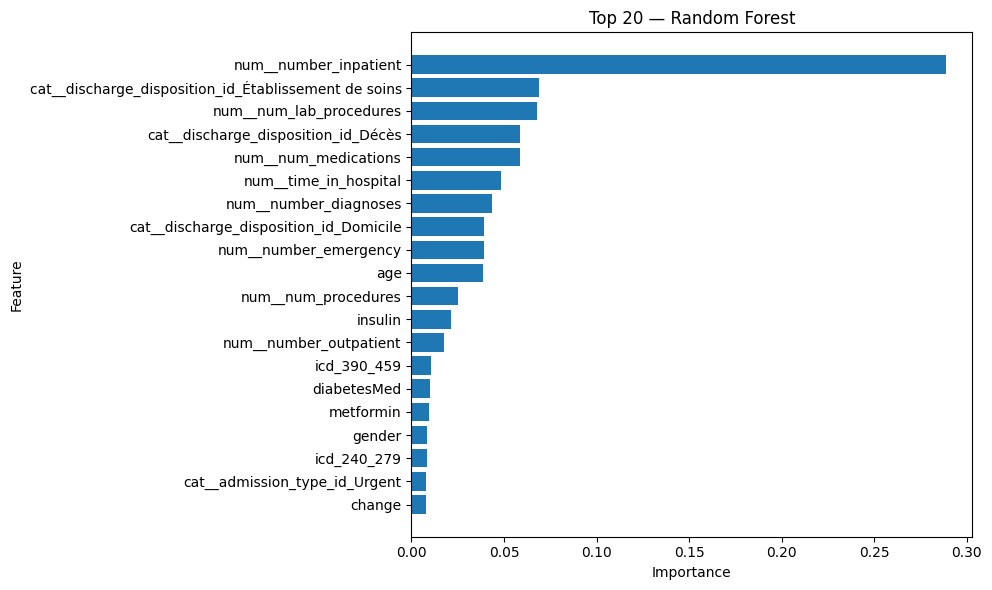

In [99]:
test = extract_feature_importance(
    model=RF,
    model_name="Random Forest",
    feature_names=feature_names
)

top20 = test.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["feature"], top20["importance"])
plt.gca().invert_yaxis()       
plt.title("Top 20 — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Modèle pour qui on ne peut pas utiliser feature_importances_ (histgradient, catboost, mlp)

### utilisations de la permutation_importance pour Histgradienr er mlp

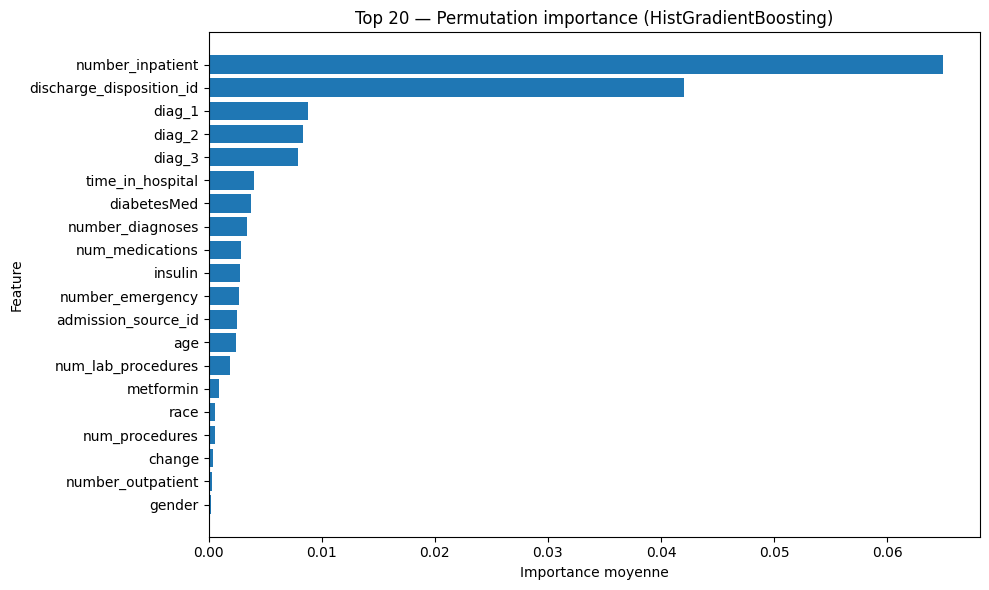

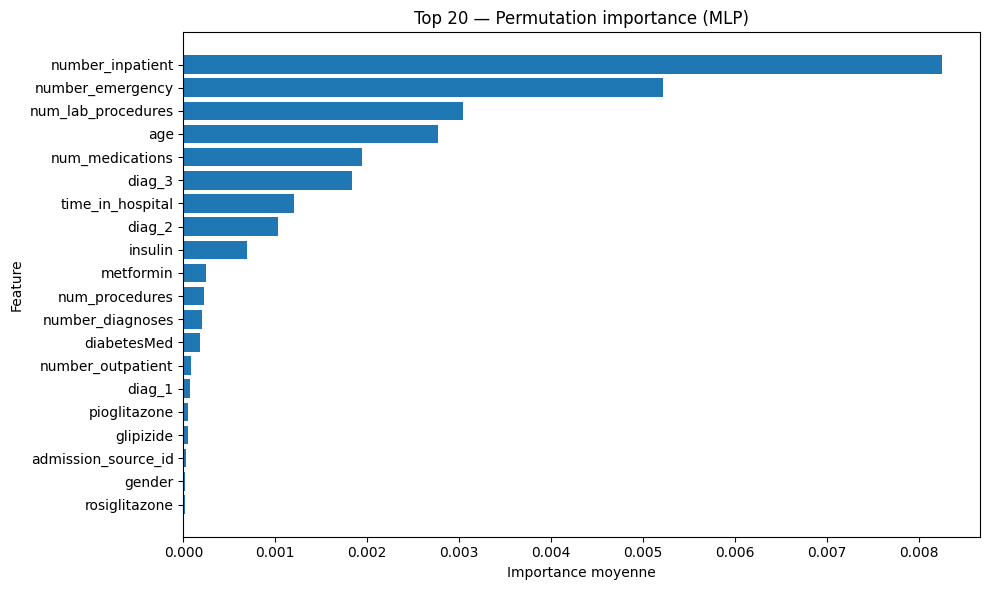

In [100]:
from sklearn.inspection import permutation_importance

def plot_perm_importance(model, X, y, title):
    r = permutation_importance(
        model,
        X,
        y,
        n_repeats=10,
        random_state=42,
        scoring="f1"
    )

    importances = r.importances_mean
    order = importances.argsort()[::-1]

    table = pd.DataFrame({
        "feature": X.columns[order],
        "importance": importances[order]
    })

    top20 = table.head(20)

    plt.figure(figsize=(10, 6))
    plt.barh(top20["feature"], top20["importance"])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("Importance moyenne")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()



hgb.fit(X_train_enc, Y_train)
plot_perm_importance(hgb, X_train_enc, Y_train,
                     "Top 20 — Permutation importance (HistGradientBoosting)")


mlp.fit(X_train_enc, Y_train)
plot_perm_importance(mlp, X_train_enc, Y_train,
                     "Top 20 — Permutation importance (MLP)")


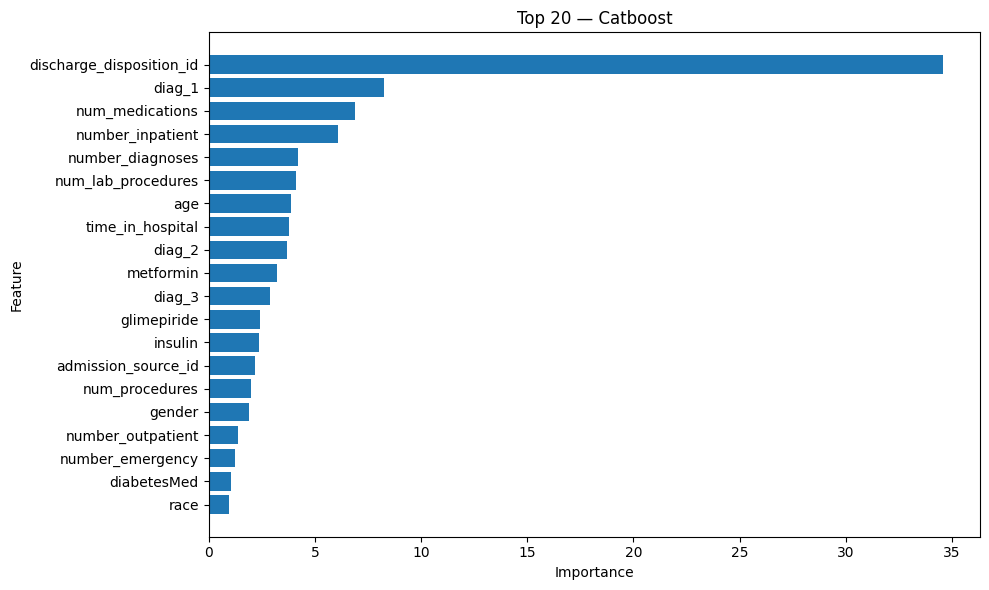

In [101]:
#catboost

importances = cat_model.get_feature_importance()


fi = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance": importances
})


top20 = fi.sort_values(by="importance", ascending=False).head(20)

# 4) Plot
plt.figure(figsize=(10, 6))
plt.barh(top20["feature"], top20["importance"])
plt.gca().invert_yaxis()   
plt.title("Top 20 — Catboost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
